# RSNA Pediatric Bone Age Estimation — Final Project
**Automated Skeletal Maturity Assessment for Orthodontic Treatment Planning Using Deep Learning**

## Pipeline Overview
1. `multi_model_train.py` — Train 7 CNN models (VGG16, ResNet50, InceptionV3, DenseNet121, EfficientNetB0, EfficientNetB3, Xception)
2. `eda_and_visualization.py` — Exploratory Data Analysis & visualization
3. `comprehensive_metrics.py` — 17 metrics across 3 categories (Regression | mAP | Classification)
4. `patient_predict.py` — Patient inference, growth stage classification & clinical report

## Motivation
Before initiating fixed orthodontic appliance (braces) therapy, orthodontists assess skeletal maturity by manually comparing hand-wrist radiographs against the Greulich-Pyle (GP) atlas. This process is time-consuming (~5-15 min per patient), subjective, and requires specialist training. This project automates the workflow using an ensemble of 7 deep learning models, producing bone age predictions with 95% confidence intervals and structured clinical reports in seconds.

**Dataset:** RSNA Pediatric Bone Age Challenge 2017 — 12,611 hand-wrist radiographs, ages 1–228 months


## 0. Setup


In [1]:
!pip install -q timm tqdm


---
## 1. Script Definitions
> The following cells write Python scripts to `/kaggle/working/`. If training is already complete and checkpoints are loaded, simply run these cells to define the scripts.


### 1.1 Multi-Model Training Script


In [2]:
%%writefile multi_model_train.py
"""
RSNA Pediatric Bone Age Challenge 2017
Multi-Model Comparison Training Pipeline
Models: VGG16, ResNet50, InceptionV3, DenseNet121, EfficientNet-B0, EfficientNet-B3
"""

import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import (
    VGG16_Weights,
    ResNet50_Weights,
    Inception_V3_Weights,
    DenseNet121_Weights,
    EfficientNet_B0_Weights,
    EfficientNet_B3_Weights,
)
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

try:
    import timm
    TIMM_AVAILABLE = True
except ImportError:
    TIMM_AVAILABLE = False
    print("timm not found — Xception will be skipped. Install: pip install timm")

# ─────────────────────────── Paths ─────────────────────────────
BASE_INPUT = Path("/kaggle/input/datasets/kmader/rsna-bone-age")
IMG_DIR    = BASE_INPUT / "boneage-training-dataset" / "boneage-training-dataset"
CSV_PATH   = BASE_INPUT / "boneage-training-dataset.csv"
OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ─────────────────────────── Config ────────────────────────────
BATCH_SIZE   = 32
NUM_EPOCHS   = 40
LR           = 1e-4
WEIGHT_DECAY = 1e-5
VAL_SPLIT    = 0.18
PATIENCE     = 8
NUM_WORKERS  = 4
SEED         = 42
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device: {DEVICE}")

# ──────────────── Model Registry ───────────────────────────────
# img_size: required input size, feature_dim: backbone output channels
MODEL_REGISTRY = {
    "VGG16":          {"img_size": 256, "feature_dim": 512},
    "ResNet50":       {"img_size": 256, "feature_dim": 2048},
    "InceptionV3":    {"img_size": 299, "feature_dim": 2048},
    "DenseNet121":    {"img_size": 256, "feature_dim": 1024},
    "EfficientNetB0": {"img_size": 256, "feature_dim": 1280},
    "EfficientNetB3": {"img_size": 300, "feature_dim": 1536},
    "Xception":       {"img_size": 299, "feature_dim": 2048},  # requires timm
}

# Models to train (modify this list to train a subset)
MODELS_TO_TRAIN = [m for m in MODEL_REGISTRY
                   if m != "Xception" or TIMM_AVAILABLE]

# ──────────────── Age Label Normalization ──────────────────────
# Inspired by top Kaggle notebooks: normalizing targets stabilizes training.
# We divide by 2*std (≈ 82 months) so labels fall in [0, ~2.8].
# All MAE values are reported in original months (denormalized).
AGE_SCALE: float = 1.0   # set in main() from training data std


# ══════════════════════════════════════════════════════════════
#  1. PREPROCESSING
# ══════════════════════════════════════════════════════════════

def apply_clahe(img_gray: np.ndarray) -> np.ndarray:
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img_gray)


def pad_to_square(img: np.ndarray) -> np.ndarray:
    h, w = img.shape
    if h == w:
        return img
    size = max(h, w)
    canvas = np.zeros((size, size), dtype=np.uint8)
    canvas[(size - h) // 2:(size - h) // 2 + h,
           (size - w) // 2:(size - w) // 2 + w] = img
    return canvas


def load_and_preprocess(img_path: str, img_size: int) -> np.ndarray:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read: {img_path}")
    img = apply_clahe(img)
    img = pad_to_square(img)
    img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)
    return np.stack([img, img, img], axis=-1)


# ══════════════════════════════════════════════════════════════
#  2. DATASET
# ══════════════════════════════════════════════════════════════

class BoneAgeDataset(Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, df: pd.DataFrame, img_dir: Path,
                 img_size: int = 256, augment: bool = False):
        self.df       = df.reset_index(drop=True)
        self.img_dir  = img_dir
        self.img_size = img_size
        self.augment  = augment

        base = [transforms.ToTensor(),
                transforms.Normalize(mean=self.MEAN, std=self.STD)]
        aug  = [transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(degrees=15),
                transforms.ColorJitter(brightness=0.1, contrast=0.1)]
        self.transform = transforms.Compose((aug if augment else []) + base)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = str(self.img_dir / f"{int(row['id'])}.png")
        img_np   = load_and_preprocess(img_path, self.img_size)
        img_pil  = Image.fromarray(img_np)
        img_t    = self.transform(img_pil)
        gender   = torch.tensor([float(row["male"])], dtype=torch.float32)
        # Normalize target: divide by AGE_SCALE (set in main from 2*std)
        raw_age  = float(row["boneage"])
        label    = torch.tensor(raw_age / AGE_SCALE, dtype=torch.float32)
        return img_t, gender, label


# ══════════════════════════════════════════════════════════════
#  3. BACKBONE WRAPPERS
# ══════════════════════════════════════════════════════════════

class _InceptionV3Features(nn.Module):
    """Extract features from InceptionV3 up to Mixed_7c (2048 channels)."""
    def __init__(self, backbone):
        super().__init__()
        self.b = backbone

    def forward(self, x):
        x = self.b.Conv2d_1a_3x3(x)
        x = self.b.Conv2d_2a_3x3(x)
        x = self.b.Conv2d_2b_3x3(x)
        x = self.b.maxpool1(x)
        x = self.b.Conv2d_3b_1x1(x)
        x = self.b.Conv2d_4a_3x3(x)
        x = self.b.maxpool2(x)
        x = self.b.Mixed_5b(x)
        x = self.b.Mixed_5c(x)
        x = self.b.Mixed_5d(x)
        x = self.b.Mixed_6a(x)
        x = self.b.Mixed_6b(x)
        x = self.b.Mixed_6c(x)
        x = self.b.Mixed_6d(x)
        x = self.b.Mixed_6e(x)
        x = self.b.Mixed_7a(x)
        x = self.b.Mixed_7b(x)
        x = self.b.Mixed_7c(x)
        return x


class _DenseNet121Features(nn.Module):
    """DenseNet121 features + ReLU (ReLU not included in m.features)."""
    def __init__(self, features):
        super().__init__()
        self.features = features

    def forward(self, x):
        return F.relu(self.features(x), inplace=True)


def build_backbone(name: str):
    """Return (feature_extractor_module, feature_dim)."""
    if name == "VGG16":
        m = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        return m.features, 512

    elif name == "ResNet50":
        m = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        # Remove avgpool and fc
        return nn.Sequential(*list(m.children())[:-2]), 2048

    elif name == "InceptionV3":
        m = models.inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)
        m.aux_logits = False
        return _InceptionV3Features(m), 2048

    elif name == "DenseNet121":
        m = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        return _DenseNet121Features(m.features), 1024

    elif name == "EfficientNetB0":
        m = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        return m.features, 1280

    elif name == "EfficientNetB3":
        m = models.efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        return m.features, 1536

    elif name == "Xception":
        if not TIMM_AVAILABLE:
            raise ImportError("timm is required for Xception. pip install timm")
        # timm Xception: global_pool='' keeps spatial dims, num_classes=0 removes head
        m = timm.create_model("xception", pretrained=True, num_classes=0, global_pool="")
        return m, 2048

    else:
        raise ValueError(f"Unknown model: {name}")


# ══════════════════════════════════════════════════════════════
#  4. UNIFIED MODEL ARCHITECTURE
# ══════════════════════════════════════════════════════════════

class BoneAgeModel(nn.Module):
    """
    Multi-input architecture for any backbone.
      Image branch  : pretrained backbone → GAP → feature_dim
      Gender branch : Linear(1→32) → ReLU
      Fusion        : Concat → FC head → scalar (regression)
    """

    def __init__(self, backbone_name: str, dropout: float = 0.4):
        super().__init__()
        self.backbone_name = backbone_name

        image_branch, feature_dim = build_backbone(backbone_name)
        self.image_branch = image_branch
        self.gap          = nn.AdaptiveAvgPool2d(1)

        self.gender_branch = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim + 32, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 1),
        )

    def forward(self, img: torch.Tensor, gender: torch.Tensor) -> torch.Tensor:
        feat   = self.gap(self.image_branch(img)).flatten(1)
        g_feat = self.gender_branch(gender)
        return self.head(torch.cat([feat, g_feat], dim=1)).squeeze(1)


# ══════════════════════════════════════════════════════════════
#  5. TRAINING LOOP
# ══════════════════════════════════════════════════════════════

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = total_mae = 0.0
    ctx = torch.enable_grad() if is_train else torch.no_grad()

    with ctx:
        for img, gender, label in tqdm(loader, leave=False):
            img, gender, label = img.to(DEVICE), gender.to(DEVICE), label.to(DEVICE)
            pred = model(img, gender)
            loss = criterion(pred, label)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(label)
            # Denormalize MAE so it's reported in original months
            total_mae  += (torch.abs(pred - label) * AGE_SCALE).sum().item()

    n = len(loader.dataset)
    return total_loss / n, total_mae / n


def train_model(model_name: str, train_df: pd.DataFrame,
                val_df: pd.DataFrame) -> dict:
    cfg      = MODEL_REGISTRY[model_name]
    img_size = cfg["img_size"]

    print(f"\n{'='*60}")
    print(f"  Training: {model_name}  (img_size={img_size})")
    print(f"{'='*60}")

    train_ds = BoneAgeDataset(train_df, IMG_DIR, img_size=img_size, augment=True)
    val_ds   = BoneAgeDataset(val_df,   IMG_DIR, img_size=img_size, augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

    model     = BoneAgeModel(model_name).to(DEVICE)
    n_params  = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_params:,}")

    # Huber delta is also normalized: 10 months / AGE_SCALE
    criterion = nn.HuberLoss(delta=10.0 / AGE_SCALE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3)

    best_val_mae  = float("inf")
    patience_cnt  = 0
    ckpt_path     = OUTPUT_DIR / f"best_{model_name}.pth"

    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_mae = run_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_mae = run_epoch(model, val_loader,   criterion)
        scheduler.step(vl_mae)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_mae"].append(tr_mae)
        history["val_mae"].append(vl_mae)

        print(f"  Ep {epoch:03d}/{NUM_EPOCHS} | "
              f"Train MAE: {tr_mae:.2f}m | Val MAE: {vl_mae:.2f}m")

        if vl_mae < best_val_mae:
            best_val_mae = vl_mae
            patience_cnt = 0
            torch.save({
                "epoch": epoch,
                "model_name": model_name,
                "model_state": model.state_dict(),
                "best_val_mae": best_val_mae,
                "age_scale": AGE_SCALE,
            }, ckpt_path)
            print(f"    ✓ Checkpoint saved (val MAE: {best_val_mae:.2f} months)")
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}.")
                break

    # Save history
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(OUTPUT_DIR / f"history_{model_name}.csv", index=False)

    print(f"\n  [{model_name}] Best Val MAE: {best_val_mae:.2f} months")
    return {"model_name": model_name, "best_val_mae": best_val_mae,
            "history": history, "ckpt_path": str(ckpt_path)}


# ══════════════════════════════════════════════════════════════
#  6. MAIN — Train All Models
# ══════════════════════════════════════════════════════════════

def main():
    global AGE_SCALE

    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--models", nargs="+", default=None,
                        help="Models to train (empty = all)")
    cli = parser.parse_args()

    # Override MODELS_TO_TRAIN if --models flag provided
    models_to_run = cli.models if cli.models else MODELS_TO_TRAIN
    unknown = [m for m in models_to_run if m not in MODEL_REGISTRY]
    if unknown:
        raise ValueError(f"Unknown model(s): {unknown}. "
                         f"Valid options: {list(MODEL_REGISTRY.keys())}")

    df = pd.read_csv(CSV_PATH)
    df["male"] = df["male"].astype(bool)
    df["age_bucket"] = pd.cut(df["boneage"], bins=10, labels=False)

    train_df, val_df = train_test_split(
        df, test_size=VAL_SPLIT,
        stratify=df["age_bucket"], random_state=SEED)
    print(f"Total: {len(df)} | Train: {len(train_df)} | Val: {len(val_df)}")

    # Age normalization scale — derived from training split (same as top Kaggle notebooks)
    AGE_SCALE = 2.0 * float(train_df["boneage"].std())
    print(f"AGE_SCALE (2×std): {AGE_SCALE:.2f} months")
    pd.Series({"age_scale": AGE_SCALE}).to_json(OUTPUT_DIR / "age_scale.json")

    results = []
    for model_name in models_to_run:
        result = train_model(model_name, train_df, val_df)
        results.append({"Model": result["model_name"],
                        "Best_Val_MAE": result["best_val_mae"]})

    # Summary table
    summary_df = pd.DataFrame(results).sort_values("Best_Val_MAE")
    summary_df.to_csv(OUTPUT_DIR / "model_comparison_summary.csv", index=False)

    print("\n" + "="*50)
    print("MODEL COMPARISON SUMMARY")
    print("="*50)
    print(summary_df.to_string(index=False))
    print(f"\nBest model: {summary_df.iloc[0]['Model']} "
          f"(MAE: {summary_df.iloc[0]['Best_Val_MAE']:.2f} months)")


if __name__ == "__main__":
    main()


Writing multi_model_train.py


### 1.2 EDA & Visualization Script


In [3]:
%%writefile eda_and_visualization.py
"""
RSNA Pediatric Bone Age — EDA & Visualization Suite
Run this script after training is complete.
All plots are saved to /kaggle/working/plots/.
"""

import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.models import (
    EfficientNet_B0_Weights, EfficientNet_B3_Weights,
    VGG16_Weights, ResNet50_Weights, Inception_V3_Weights,
    DenseNet121_Weights,
)
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# ─────────────────────────── Paths & Config ────────────────────
BASE_INPUT = Path("/kaggle/input/datasets/kmader/rsna-bone-age")
IMG_DIR    = BASE_INPUT / "boneage-training-dataset" / "boneage-training-dataset"
CSV_PATH   = BASE_INPUT / "boneage-training-dataset.csv"
OUTPUT_DIR = Path("/kaggle/working")
PLOT_DIR   = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Model priority order: use the best available checkpoint
MODEL_PRIORITY = [
    "EfficientNetB3", "EfficientNetB0", "DenseNet121",
    "ResNet50", "InceptionV3", "VGG16",
]
MODEL_IMG_SIZE = {
    "VGG16": 256, "ResNet50": 256, "InceptionV3": 299,
    "DenseNet121": 256, "EfficientNetB0": 256, "EfficientNetB3": 300,
}

SEED      = 42
VAL_SPLIT = 0.18
IMG_SIZE  = 256   # default; overridden per model
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
COLORS = {"male": "#4C72B0", "female": "#DD8452", "train": "#2ecc71", "val": "#e74c3c"}

np.random.seed(SEED)


# ══════════════════════════════════════════════════════════════
#  HELPERS
# ══════════════════════════════════════════════════════════════

def save(fig, name):
    path = PLOT_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved → {path}")


def apply_clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img)


def pad_to_square(img):
    h, w = img.shape
    if h == w:
        return img
    size = max(h, w)
    canvas = np.zeros((size, size), dtype=np.uint8)
    canvas[(size-h)//2:(size-h)//2+h, (size-w)//2:(size-w)//2+w] = img
    return canvas


def load_img(img_path, size=IMG_SIZE):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = apply_clahe(img)
    img = pad_to_square(img)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    return img


# ══════════════════════════════════════════════════════════════
#  1. EDA — METADATA
# ══════════════════════════════════════════════════════════════

def eda_metadata(df):
    print("\n[1/7] EDA — Metadata plots...")

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle("RSNA Bone Age — Metadata EDA", fontsize=16, fontweight="bold")

    # 1a. Age distribution — histogram + KDE
    ax = axes[0, 0]
    sns.histplot(df["boneage"], bins=40, kde=True, color="#5B84B1", ax=ax)
    mean_val   = df["boneage"].mean()
    median_val = df["boneage"].median()
    ax.axvline(mean_val,   color="red",    ls="--", lw=1.5, label=f"Mean: {mean_val:.1f}")
    ax.axvline(median_val, color="orange", ls="--", lw=1.5, label=f"Median: {median_val:.1f}")
    ax.set_title("Bone Age Distribution (months)")
    ax.set_xlabel("Bone Age (months)")
    ax.legend()

    # 1b. Gender distribution
    ax = axes[0, 1]
    counts = df["male"].value_counts()
    labels = ["Male" if v else "Female" for v in counts.index]
    colors = [COLORS["male"], COLORS["female"]]
    wedges, texts, autotexts = ax.pie(
        counts, labels=labels, colors=colors,
        autopct="%1.1f%%", startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2}
    )
    for at in autotexts:
        at.set_fontsize(12)
    ax.set_title("Gender Distribution")

    # 1c. Age distribution by gender — violin
    ax = axes[0, 2]
    df_plot = df.copy()
    df_plot["Gender"] = df_plot["male"].map({True: "Male", False: "Female"})
    sns.violinplot(data=df_plot, x="Gender", y="boneage",
                   palette={"Male": COLORS["male"], "Female": COLORS["female"]},
                   inner="box", ax=ax)
    ax.set_title("Bone Age by Gender")
    ax.set_ylabel("Bone Age (months)")

    # 1d. Sample count by age group
    ax = axes[1, 0]
    df_plot2 = df.copy()
    df_plot2["Age Group"] = pd.cut(
        df_plot2["boneage"],
        bins=[0, 24, 60, 120, 180, 228],
        labels=["0-2y", "2-5y", "5-10y", "10-15y", "15-19y"]
    )
    group_counts = df_plot2.groupby(["Age Group", df_plot2["male"].map({True:"Male", False:"Female"})]).size().unstack()
    group_counts.plot(kind="bar", ax=ax, color=[COLORS["female"], COLORS["male"]], edgecolor="white")
    ax.set_title("Sample Count by Age Group")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Gender")

    # 1e. Box plot — by gender
    ax = axes[1, 1]
    sns.boxplot(data=df_plot, x="Gender", y="boneage",
                palette={"Male": COLORS["male"], "Female": COLORS["female"]},
                width=0.4, ax=ax)
    ax.set_title("Box Plot — Bone Age")
    ax.set_ylabel("Bone Age (months)")

    # 1f. Summary statistics table
    ax = axes[1, 2]
    ax.axis("off")
    stats_df = df.groupby(df["male"].map({True:"Male", False:"Female"}))["boneage"].describe().round(1)
    table = ax.table(
        cellText=stats_df.values,
        rowLabels=stats_df.index,
        colLabels=stats_df.columns,
        cellLoc="center", loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.6)
    ax.set_title("Summary Statistics", pad=20)

    plt.tight_layout()
    save(fig, "01_eda_metadata.png")


# ══════════════════════════════════════════════════════════════
#  2. EDA — IMAGE ANALYSIS
# ══════════════════════════════════════════════════════════════

def eda_images(df, n_samples=12):
    print("[2/7] EDA — Sample images (before/after CLAHE)...")

    sample_rows = df.sample(n=6, random_state=SEED)

    fig, axes = plt.subplots(4, 6, figsize=(20, 14))
    fig.suptitle("Sample Radiographs: Raw vs CLAHE Processed", fontsize=14, fontweight="bold")

    for col_idx, (_, row) in enumerate(sample_rows.iterrows()):
        img_path = str(IMG_DIR / f"{int(row['id'])}.png")
        raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if raw is None:
            continue

        # Row 0: Raw image
        raw_sq = pad_to_square(raw)
        raw_rs = cv2.resize(raw_sq, (IMG_SIZE, IMG_SIZE))
        axes[0, col_idx].imshow(raw_rs, cmap="bone")
        axes[0, col_idx].set_title(
            f"{'M' if row['male'] else 'F'} | {int(row['boneage'])}mo",
            fontsize=9
        )
        axes[0, col_idx].axis("off")

        # Row 1: Histogram (raw)
        axes[1, col_idx].hist(raw_rs.ravel(), bins=50, color="#5B84B1", alpha=0.8)
        axes[1, col_idx].set_xlim(0, 255)
        axes[1, col_idx].set_yticks([])
        axes[1, col_idx].set_xlabel("Pixel Value", fontsize=7)

        # Row 2: CLAHE applied
        clahe_img = apply_clahe(raw)
        clahe_sq  = pad_to_square(clahe_img)
        clahe_rs  = cv2.resize(clahe_sq, (IMG_SIZE, IMG_SIZE))
        axes[2, col_idx].imshow(clahe_rs, cmap="bone")
        axes[2, col_idx].set_title("CLAHE", fontsize=9)
        axes[2, col_idx].axis("off")

        # Row 3: Histogram (CLAHE)
        axes[3, col_idx].hist(clahe_rs.ravel(), bins=50, color="#DD8452", alpha=0.8)
        axes[3, col_idx].set_xlim(0, 255)
        axes[3, col_idx].set_yticks([])
        axes[3, col_idx].set_xlabel("Pixel Value", fontsize=7)

    # Row labels
    for row_i, label in enumerate(["Raw Image", "Raw Histogram", "CLAHE Image", "CLAHE Histogram"]):
        axes[row_i, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=10)

    plt.tight_layout()
    save(fig, "02_eda_images_clahe.png")


def eda_image_stats(df, n=500):
    print("[3/7] EDA — Image size & brightness statistics...")

    sample = df.sample(min(n, len(df)), random_state=SEED)
    heights, widths, means, stds = [], [], [], []

    for _, row in sample.iterrows():
        img = cv2.imread(str(IMG_DIR / f"{int(row['id'])}.png"), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        heights.append(img.shape[0])
        widths.append(img.shape[1])
        means.append(img.mean())
        stds.append(img.std())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Image Statistics (n=500 samples)", fontsize=13, fontweight="bold")

    # Size scatter
    axes[0].scatter(widths, heights, alpha=0.4, s=15, color="#5B84B1")
    axes[0].set_xlabel("Width (px)")
    axes[0].set_ylabel("Height (px)")
    axes[0].set_title("Image Size Distribution")
    axes[0].axline((0,0), slope=1, color="red", ls="--", lw=1, label="Square")
    axes[0].legend()

    # Brightness distribution
    axes[1].hist(means, bins=30, color="#2ecc71", edgecolor="white", alpha=0.85)
    axes[1].set_xlabel("Mean Pixel Value")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("Image Brightness Distribution")

    # Contrast distribution
    axes[2].hist(stds, bins=30, color="#e74c3c", edgecolor="white", alpha=0.85)
    axes[2].set_xlabel("Pixel Std Deviation")
    axes[2].set_ylabel("Frequency")
    axes[2].set_title("Image Contrast Distribution")

    plt.tight_layout()
    save(fig, "03_eda_image_stats.png")


# ══════════════════════════════════════════════════════════════
#  3. TRAINING CURVES
# ══════════════════════════════════════════════════════════════

def plot_training_curves(history_path=None):
    print("[4/7] Training curves...")

    # If history_path not provided, find the best available model's history
    if history_path is None or not Path(history_path).exists():
        model_name, _ = _find_best_checkpoint()
        if model_name:
            history_path = OUTPUT_DIR / f"history_{model_name}.csv"
        # fallback: legacy single-model history
        if history_path is None or not Path(history_path).exists():
            history_path = OUTPUT_DIR / "training_history.csv"

    if not Path(history_path).exists():
        print("  training_history.csv not found, skipping.")
        return

    hist = pd.read_csv(history_path)
    epochs = range(1, len(hist) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training History", fontsize=14, fontweight="bold")

    # Loss
    ax = axes[0]
    ax.plot(epochs, hist["train_loss"], color=COLORS["train"], lw=2, label="Train Loss")
    ax.plot(epochs, hist["val_loss"],   color=COLORS["val"],   lw=2, label="Val Loss")
    best_ep = hist["val_loss"].idxmin() + 1
    ax.axvline(best_ep, color="gray", ls="--", lw=1, label=f"Best epoch: {best_ep}")
    ax.fill_between(epochs, hist["train_loss"], hist["val_loss"], alpha=0.08, color="purple")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Huber Loss")
    ax.set_title("Train vs Validation Loss")
    ax.legend()

    # MAE
    ax = axes[1]
    ax.plot(epochs, hist["train_mae"], color=COLORS["train"], lw=2, label="Train MAE")
    ax.plot(epochs, hist["val_mae"],   color=COLORS["val"],   lw=2, label="Val MAE")
    best_mae = hist["val_mae"].min()
    best_ep2 = hist["val_mae"].idxmin() + 1
    ax.axvline(best_ep2, color="gray", ls="--", lw=1, label=f"Best: {best_mae:.2f}m (ep {best_ep2})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE (months)")
    ax.set_title("Train vs Validation MAE")
    ax.legend()

    plt.tight_layout()
    save(fig, "04_training_curves.png")


# ══════════════════════════════════════════════════════════════
#  4. MODEL PREDICTION ANALYSIS
# ══════════════════════════════════════════════════════════════

# ══════════════════════════════════════════════════════════════
#  MODEL + INFERENCE (compatible with multi-model system)
# ══════════════════════════════════════════════════════════════

class _InceptionV3Features(nn.Module):
    def __init__(self, b):
        super().__init__()
        self.b = b

    def forward(self, x):
        x = self.b.Conv2d_1a_3x3(x); x = self.b.Conv2d_2a_3x3(x)
        x = self.b.Conv2d_2b_3x3(x); x = self.b.maxpool1(x)
        x = self.b.Conv2d_3b_1x1(x); x = self.b.Conv2d_4a_3x3(x)
        x = self.b.maxpool2(x)
        for block in [self.b.Mixed_5b, self.b.Mixed_5c, self.b.Mixed_5d,
                      self.b.Mixed_6a, self.b.Mixed_6b, self.b.Mixed_6c,
                      self.b.Mixed_6d, self.b.Mixed_6e,
                      self.b.Mixed_7a, self.b.Mixed_7b, self.b.Mixed_7c]:
            x = block(x)
        return x


class _DenseFeatures(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.features = features

    def forward(self, x):
        return F.relu(self.features(x), inplace=True)


def _backbone(name):
    if name == "VGG16":
        m = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        return m.features, 512
    elif name == "ResNet50":
        m = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        return nn.Sequential(*list(m.children())[:-2]), 2048
    elif name == "InceptionV3":
        m = models.inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)
        m.aux_logits = False
        return _InceptionV3Features(m), 2048
    elif name == "DenseNet121":
        m = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        return _DenseFeatures(m.features), 1024
    elif name == "EfficientNetB0":
        m = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        return m.features, 1280
    elif name == "EfficientNetB3":
        m = models.efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        return m.features, 1536
    else:
        raise ValueError(name)


class BoneAgeModel(nn.Module):
    def __init__(self, backbone_name, dropout=0.4):
        super().__init__()
        ib, fd = _backbone(backbone_name)
        self.image_branch  = ib
        self.gap           = nn.AdaptiveAvgPool2d(1)
        self.gender_branch = nn.Sequential(nn.Linear(1, 32), nn.ReLU(inplace=True))
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fd + 32, 512), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 1),
        )

    def forward(self, img, gender):
        f = self.gap(self.image_branch(img)).flatten(1)
        return self.head(torch.cat([f, self.gender_branch(gender)], dim=1)).squeeze(1)


class _InferDataset(torch.utils.data.Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, df, img_dir, img_size=256):
        self.df       = df.reset_index(drop=True)
        self.img_dir  = img_dir
        self.img_size = img_size
        self.tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=self.MEAN, std=self.STD),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = str(self.img_dir / f"{int(row['id'])}.png")
        img      = load_img(img_path)
        if img is None:
            img = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = np.stack([img] * 3, axis=-1)
        return (
            self.tf(Image.fromarray(img)),
            torch.tensor([float(row["male"])], dtype=torch.float32),
            torch.tensor(float(row["boneage"]), dtype=torch.float32),
        )


def _find_best_checkpoint():
    """Return (model_name, ckpt_path) for the best available checkpoint."""
    for name in MODEL_PRIORITY:
        p = OUTPUT_DIR / f"best_{name}.pth"
        if p.exists():
            return name, p
    # fallback: legacy single-model checkpoint
    legacy = OUTPUT_DIR / "best_model.pth"
    if legacy.exists():
        return "EfficientNetB0", legacy
    return None, None


def get_predictions(df_val):
    model_name, ckpt_path = _find_best_checkpoint()
    if ckpt_path is None:
        print("  Checkpoint not found, skipping prediction plots.")
        return None, None, None

    print(f"  Using model for inference: {model_name}")
    ckpt      = torch.load(ckpt_path, map_location=DEVICE)
    age_scale = ckpt.get("age_scale", 1.0)
    img_size  = MODEL_IMG_SIZE.get(model_name, 256)

    model = BoneAgeModel(model_name).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    ds     = _InferDataset(df_val, IMG_DIR, img_size=img_size)
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=2)

    preds, trues, genders = [], [], []
    with torch.no_grad():
        for img, gender, label in loader:
            out = model(img.to(DEVICE), gender.to(DEVICE))
            preds.extend((out.cpu().numpy() * age_scale).tolist())
            trues.extend(label.numpy().tolist())
            genders.extend(gender.squeeze(1).numpy().tolist())

    return np.array(preds), np.array(trues), np.array(genders)


def plot_prediction_analysis(df_val):
    print("[5/7] Prediction analysis plots...")

    preds, trues, genders = get_predictions(df_val)
    if preds is None:
        return

    errors = preds - trues

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle("Model Prediction Analysis (Validation Set)", fontsize=15, fontweight="bold")

    gender_labels = np.where(genders == 1.0, "Male", "Female")
    palette = {"Male": COLORS["male"], "Female": COLORS["female"]}

    # 5a. Predicted vs True scatter
    ax = axes[0, 0]
    for g, c in palette.items():
        mask = gender_labels == g
        ax.scatter(trues[mask], preds[mask], alpha=0.35, s=12, color=c, label=g)
    mn, mx = trues.min(), trues.max()
    ax.plot([mn, mx], [mn, mx], "r--", lw=1.5, label="Perfect prediction")
    ax.set_xlabel("True Bone Age (months)")
    ax.set_ylabel("Predicted Age (months)")
    ax.set_title("Predicted vs True")
    ax.legend(markerscale=2)

    mae  = np.abs(errors).mean()
    rmse = np.sqrt((errors**2).mean())
    ax.text(0.05, 0.95, f"MAE: {mae:.2f}m\nRMSE: {rmse:.2f}m",
            transform=ax.transAxes, va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    # 5b. Residual distribution
    ax = axes[0, 1]
    sns.histplot(errors, bins=50, kde=True, color="#8E44AD", ax=ax)
    ax.axvline(0, color="red", ls="--", lw=1.5, label="Zero error")
    ax.set_xlabel("Error (Predicted - True, months)")
    bias_val = errors.mean()
    ax.set_title(f"Residual Distribution  |  Bias: {bias_val:.2f}m")
    ax.legend()

    # 5c. Residual vs Predicted (heteroscedasticity check)
    ax = axes[0, 2]
    for g, c in palette.items():
        mask = gender_labels == g
        ax.scatter(preds[mask], errors[mask], alpha=0.3, s=12, color=c, label=g)
    ax.axhline(0, color="red", ls="--", lw=1.5)
    ax.set_xlabel("Predicted (months)")
    ax.set_ylabel("Residual Error (months)")
    ax.set_title("Residual vs Predicted (Heteroscedasticity)")
    ax.legend(markerscale=2)

    # 5d. Bland-Altman plot
    ax = axes[1, 0]
    mean_vals = (preds + trues) / 2
    ax.scatter(mean_vals, errors, alpha=0.3, s=12, color="#16A085")
    mean_err = errors.mean()
    std_err  = errors.std()
    lo_lim   = mean_err - 1.96 * std_err
    hi_lim   = mean_err + 1.96 * std_err
    ax.axhline(mean_err, color="red",  ls="-",  lw=1.5, label=f"Mean: {mean_err:.2f}")
    ax.axhline(hi_lim,   color="blue", ls="--", lw=1,   label=f"+1.96σ: {hi_lim:.2f}")
    ax.axhline(lo_lim,   color="blue", ls="--", lw=1,   label=f"-1.96σ: {lo_lim:.2f}")
    ax.set_xlabel("Mean (months)")
    ax.set_ylabel("Difference (months)")
    ax.set_title("Bland-Altman Analysis")
    ax.legend(fontsize=8)

    # 5e. MAE by age group
    ax = axes[1, 1]
    bins   = [0, 24, 60, 120, 180, 228]
    labels = ["0-2y", "2-5y", "5-10y", "10-15y", "15-19y"]
    bucket = pd.cut(trues, bins=bins, labels=labels)
    mae_by_group = pd.Series(np.abs(errors)).groupby(bucket).mean()
    colors_bar = sns.color_palette("Blues_d", len(mae_by_group))
    mae_by_group.plot(kind="bar", ax=ax, color=colors_bar, edgecolor="white")
    ax.set_title("MAE by Age Group")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("MAE (months)")
    ax.tick_params(axis="x", rotation=0)

    # 5f. Q-Q plot (normality test)
    ax = axes[1, 2]
    (osm, osr), (slope, intercept, r) = stats.probplot(errors, dist="norm")
    ax.scatter(osm, osr, alpha=0.4, s=12, color="#E67E22")
    ax.plot(osm, slope*np.array(osm)+intercept, "r-", lw=1.5, label=f"R²={r**2:.3f}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")
    ax.set_title("Q-Q Plot (Residual Normality)")
    ax.legend()

    plt.tight_layout()
    save(fig, "05_prediction_analysis.png")
    return preds, trues, genders


# ══════════════════════════════════════════════════════════════
#  5. CONFUSION MATRIX (Age Groups)
# ══════════════════════════════════════════════════════════════

def plot_confusion_matrix(preds, trues):
    print("[6/7] Confusion matrix (age groups)...")

    bins   = [0, 24, 60, 120, 180, 228]
    labels = ["0-2y", "2-5y", "5-10y", "10-15y", "15-19y"]

    true_cls = pd.cut(trues, bins=bins, labels=labels)
    pred_cls = pd.cut(np.clip(preds, 0, 228), bins=bins, labels=labels)

    # Remove NaN values
    mask = (~true_cls.isna()) & (~pred_cls.isna())
    true_cls = true_cls[mask]
    pred_cls = pred_cls[mask]

    cm = confusion_matrix(true_cls, pred_cls, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Confusion Matrix — Age Groups (Regression → Classification)", fontsize=13, fontweight="bold")

    # Raw counts
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=axes[0],
                linewidths=0.5, cbar_kws={"label": "Sample Count"})
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Raw Counts")

    # Normalized (recall)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="YlOrRd",
                xticklabels=labels, yticklabels=labels, ax=axes[1],
                linewidths=0.5, vmin=0, vmax=1, cbar_kws={"label": "Recall Ratio"})
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Normalized (Row = Recall)")

    plt.tight_layout()
    save(fig, "06_confusion_matrix.png")


# ══════════════════════════════════════════════════════════════
#  6. SUMMARY DASHBOARD
# ══════════════════════════════════════════════════════════════

def plot_summary_dashboard(df, preds, trues, history_path):
    print("[7/7] Summary dashboard...")

    hist = pd.read_csv(history_path) if history_path.exists() else None

    fig = plt.figure(figsize=(22, 14))
    fig.suptitle("RSNA Bone Age — Project Summary Dashboard", fontsize=16, fontweight="bold", y=1.01)
    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

    # Age distribution
    ax1 = fig.add_subplot(gs[0, 0])
    sns.histplot(df["boneage"], bins=30, kde=True, color="#5B84B1", ax=ax1)
    ax1.set_title("Age Distribution")
    ax1.set_xlabel("Month")

    # Gender
    ax2 = fig.add_subplot(gs[0, 1])
    counts = df["male"].value_counts()
    ax2.pie(counts, labels=["Male", "Female"], colors=[COLORS["male"], COLORS["female"]],
            autopct="%1.1f%%", startangle=90)
    ax2.set_title("Gender")

    # Train/Val Loss
    ax3 = fig.add_subplot(gs[0, 2])
    if hist is not None:
        ax3.plot(hist["train_loss"], color=COLORS["train"], label="Train")
        ax3.plot(hist["val_loss"],   color=COLORS["val"],   label="Val")
        ax3.set_title("Loss")
        ax3.legend(fontsize=8)
        ax3.set_xlabel("Epoch")

    # Train/Val MAE
    ax4 = fig.add_subplot(gs[0, 3])
    if hist is not None:
        ax4.plot(hist["train_mae"], color=COLORS["train"], label="Train")
        ax4.plot(hist["val_mae"],   color=COLORS["val"],   label="Val")
        ax4.set_title("MAE (months)")
        ax4.legend(fontsize=8)
        ax4.set_xlabel("Epoch")

    # Predicted vs True
    ax5 = fig.add_subplot(gs[1, :2])
    if preds is not None:
        ax5.scatter(trues, preds, alpha=0.3, s=8, color="#8E44AD")
        mn, mx = trues.min(), trues.max()
        ax5.plot([mn, mx], [mn, mx], "r--", lw=1.5)
        mae = np.abs(preds - trues).mean()
        ax5.set_title(f"Predicted vs True  |  MAE: {mae:.2f} months")
        ax5.set_xlabel("True (months)")
        ax5.set_ylabel("Predicted (months)")

    # Error distribution
    ax6 = fig.add_subplot(gs[1, 2:])
    if preds is not None:
        errors = preds - trues
        sns.histplot(errors, bins=40, kde=True, color="#E67E22", ax=ax6)
        ax6.axvline(0, color="red", ls="--", lw=1.5)
        ax6.set_title("Error Distribution")
        ax6.set_xlabel("Error (months)")

    # Summary table
    ax7 = fig.add_subplot(gs[2, :])
    ax7.axis("off")
    if preds is not None and hist is not None:
        best_mae = hist["val_mae"].min()
        best_ep  = hist["val_mae"].idxmin() + 1
        total_ep = len(hist)
        rmse     = np.sqrt(((preds - trues)**2).mean())
        bias     = (preds - trues).mean()
        summary = [
            ["Total Samples",  f"{len(df):,}"],
            ["Train / Val",    f"{int(len(df)*(1-VAL_SPLIT)):,} / {int(len(df)*VAL_SPLIT):,}"],
            ["Best Epoch",     f"{best_ep} / {total_ep}"],
            ["Best Val MAE",   f"{best_mae:.2f} months"],
            ["RMSE",           f"{rmse:.2f} months"],
            ["Bias",           f"{bias:.2f} months"],
        ]
        table = ax7.table(
            cellText=[[r[1] for r in summary]],
            colLabels=[r[0] for r in summary],
            cellLoc="center", loc="center"
        )
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 2.2)
        ax7.set_title("Summary Metrics", pad=15)

    save(fig, "00_summary_dashboard.png")


# ══════════════════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════════════════

def main():
    print(f"Plots → {PLOT_DIR}\n")

    df = pd.read_csv(CSV_PATH)
    df["male"] = df["male"].astype(bool)

    df["age_bucket"] = pd.cut(df["boneage"], bins=10, labels=False)
    _, val_df = train_test_split(df, test_size=VAL_SPLIT, stratify=df["age_bucket"], random_state=SEED)

    # EDA
    eda_metadata(df)
    eda_images(df)
    eda_image_stats(df)

    # Training curves (auto-finds the best checkpoint's history)
    plot_training_curves()

    # Prediction analysis
    result = plot_prediction_analysis(val_df)
    preds, trues = (result[0], result[1]) if result is not None else (None, None)

    # Confusion matrix
    if preds is not None:
        plot_confusion_matrix(preds, trues)

    # Summary dashboard
    model_name, _ = _find_best_checkpoint()
    best_hist = OUTPUT_DIR / f"history_{model_name}.csv" if model_name else OUTPUT_DIR / "training_history.csv"
    plot_summary_dashboard(df, preds, trues, best_hist)

    print(f"\nAll plots saved → {PLOT_DIR}")
    print("Files:")
    for f in sorted(PLOT_DIR.iterdir()):
        print(f"  {f.name}")


if __name__ == "__main__":
    main()


Writing eda_and_visualization.py


### 1.3 Comprehensive Metrics Script


In [4]:
%%writefile comprehensive_metrics.py
"""
RSNA Bone Age — Comprehensive Evaluation & Model Comparison

Metric categories:
  1. REGRESSION    : MAE, MSE, RMSE, MAPE, Median AE, R², Explained Variance
  2. mAP (adapted) : AP@3m, AP@6m, AP@12m, AP@24m, mAP
  3. CLASSIFICATION: Accuracy, Precision (macro/weighted), Recall (macro/weighted),
                     F1 (macro/weighted), Cohen's Kappa
"""

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.models import (
    VGG16_Weights, ResNet50_Weights, Inception_V3_Weights,
    DenseNet121_Weights, EfficientNet_B0_Weights, EfficientNet_B3_Weights,
)
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    median_absolute_error, explained_variance_score,
    mean_absolute_percentage_error,
    accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score, classification_report,
    confusion_matrix,
)

# ─────────────────────────── Paths ─────────────────────────────
BASE_INPUT = Path("/kaggle/input/datasets/kmader/rsna-bone-age")
IMG_DIR    = BASE_INPUT / "boneage-training-dataset" / "boneage-training-dataset"
CSV_PATH   = BASE_INPUT / "boneage-training-dataset.csv"
OUTPUT_DIR = Path("/kaggle/working")
PLOT_DIR   = OUTPUT_DIR / "eval_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

SEED      = 42
VAL_SPLIT = 0.18
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)

# Age bucket labels for classification metrics
AGE_BINS   = [0, 24, 60, 120, 180, 228]
AGE_LABELS = ["0-2y", "2-5y", "5-10y", "10-15y", "15-19y"]

# Models registered in multi_model_train.py
MODEL_REGISTRY = {
    "VGG16":          {"img_size": 256, "feature_dim": 512},
    "ResNet50":       {"img_size": 256, "feature_dim": 2048},
    "InceptionV3":    {"img_size": 299, "feature_dim": 2048},
    "DenseNet121":    {"img_size": 256, "feature_dim": 1024},
    "EfficientNetB0": {"img_size": 256, "feature_dim": 1280},
    "EfficientNetB3": {"img_size": 300, "feature_dim": 1536},
    "Xception":       {"img_size": 299, "feature_dim": 2048},
}


# ══════════════════════════════════════════════════════════════
#  1. MODEL DEFINITIONS (same as multi_model_train.py)
# ══════════════════════════════════════════════════════════════

def apply_clahe(img):
    import cv2
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img)


def pad_to_square(img):
    h, w = img.shape
    if h == w:
        return img
    size = max(h, w)
    canvas = np.zeros((size, size), dtype=np.uint8)
    canvas[(size-h)//2:(size-h)//2+h, (size-w)//2:(size-w)//2+w] = img
    return canvas


def load_img(img_path, img_size):
    import cv2
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.zeros((img_size, img_size, 3), dtype=np.uint8)
    img = apply_clahe(img)
    img = pad_to_square(img)
    img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)
    return np.stack([img, img, img], axis=-1)


class _InferDataset(torch.utils.data.Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, df, img_dir, img_size):
        self.df       = df.reset_index(drop=True)
        self.img_dir  = img_dir
        self.img_size = img_size
        self.tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=self.MEAN, std=self.STD),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = load_img(self.img_dir / f"{int(row['id'])}.png", self.img_size)
        return (
            self.tf(Image.fromarray(img)),
            torch.tensor([float(row["male"])], dtype=torch.float32),
            torch.tensor(float(row["boneage"]), dtype=torch.float32),
        )


class _InceptionV3Features(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.b = backbone

    def forward(self, x):
        x = self.b.Conv2d_1a_3x3(x);  x = self.b.Conv2d_2a_3x3(x)
        x = self.b.Conv2d_2b_3x3(x);  x = self.b.maxpool1(x)
        x = self.b.Conv2d_3b_1x1(x);  x = self.b.Conv2d_4a_3x3(x)
        x = self.b.maxpool2(x)
        x = self.b.Mixed_5b(x);  x = self.b.Mixed_5c(x);  x = self.b.Mixed_5d(x)
        x = self.b.Mixed_6a(x);  x = self.b.Mixed_6b(x);  x = self.b.Mixed_6c(x)
        x = self.b.Mixed_6d(x);  x = self.b.Mixed_6e(x)
        x = self.b.Mixed_7a(x);  x = self.b.Mixed_7b(x);  x = self.b.Mixed_7c(x)
        return x


class _DenseNet121Features(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.features = features

    def forward(self, x):
        return F.relu(self.features(x), inplace=True)


def _build_backbone(name):
    if name == "VGG16":
        m = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        return m.features, 512
    elif name == "ResNet50":
        m = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        return nn.Sequential(*list(m.children())[:-2]), 2048
    elif name == "InceptionV3":
        m = models.inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)
        m.aux_logits = False
        return _InceptionV3Features(m), 2048
    elif name == "DenseNet121":
        m = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        return _DenseNet121Features(m.features), 1024
    elif name == "EfficientNetB0":
        m = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        return m.features, 1280
    elif name == "EfficientNetB3":
        m = models.efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        return m.features, 1536
    elif name == "Xception":
        import timm
        m = timm.create_model("xception", pretrained=False, num_classes=0, global_pool="")
        return m, 2048
    else:
        raise ValueError(f"Unknown: {name}")


class BoneAgeModel(nn.Module):
    def __init__(self, backbone_name, dropout=0.4):
        super().__init__()
        self.backbone_name = backbone_name
        image_branch, feature_dim = _build_backbone(backbone_name)
        self.image_branch = image_branch
        self.gap           = nn.AdaptiveAvgPool2d(1)
        self.gender_branch = nn.Sequential(nn.Linear(1, 32), nn.ReLU(inplace=True))
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim + 32, 512), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 1),
        )

    def forward(self, img, gender):
        feat   = self.gap(self.image_branch(img)).flatten(1)
        g_feat = self.gender_branch(gender)
        return self.head(torch.cat([feat, g_feat], dim=1)).squeeze(1)


# ══════════════════════════════════════════════════════════════
#  2. INFERENCE — Get predictions from a saved checkpoint
# ══════════════════════════════════════════════════════════════

def get_predictions(model_name: str, val_df: pd.DataFrame):
    ckpt_path = OUTPUT_DIR / f"best_{model_name}.pth"
    if not ckpt_path.exists():
        print(f"  [{model_name}] Checkpoint not found: {ckpt_path}")
        return None, None, None

    ckpt     = torch.load(ckpt_path, map_location=DEVICE)
    age_scale = ckpt.get("age_scale", 1.0)

    model = BoneAgeModel(model_name).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    img_size = MODEL_REGISTRY[model_name]["img_size"]
    ds       = _InferDataset(val_df, IMG_DIR, img_size)
    loader   = DataLoader(ds, batch_size=64, shuffle=False, num_workers=2)

    preds, trues, genders = [], [], []
    with torch.no_grad():
        for img, gender, label in loader:
            out = model(img.to(DEVICE), gender.to(DEVICE))
            # Denormalize predictions to original months
            preds.extend((out.cpu().numpy() * age_scale).tolist())
            trues.extend(label.numpy().tolist())
            genders.extend(gender.squeeze(1).numpy().tolist())

    return np.array(preds), np.array(trues), np.array(genders)


# ══════════════════════════════════════════════════════════════
#  3. METRIC SUITE
# ══════════════════════════════════════════════════════════════

def adapted_map(y_true: np.ndarray, y_pred: np.ndarray,
                thresholds=(3, 6, 12, 24)) -> float:
    """
    Adapted mAP for regression.
    At each error threshold t, compute precision = fraction of samples
    where |pred - true| <= t.  Average across all thresholds.
    """
    return float(np.mean([np.mean(np.abs(y_pred - y_true) <= t)
                          for t in thresholds]))


def age_to_bucket(ages: np.ndarray) -> np.ndarray:
    return pd.cut(np.clip(ages, 0, 228), bins=AGE_BINS,
                  labels=AGE_LABELS).astype(str)


def compute_all_metrics(y_true: np.ndarray,
                        y_pred: np.ndarray,
                        model_name: str = "") -> dict:
    """
    Three metric categories:

    1. REGRESSION  — MAE, MSE, RMSE, MAPE, Median AE, R², Explained Variance
    2. mAP         — Adapted mAP at thresholds [3, 6, 12, 24] months
                     (AP@3m, AP@6m, AP@12m, AP@24m, mAP)
    3. CLASSIFICATION (age buckets: 0-2y, 2-5y, 5-10y, 10-15y, 15-19y)
                   — Accuracy, Precision macro/weighted,
                     Recall macro/weighted, F1 macro/weighted, Cohen's Kappa
    """
    errors    = y_pred - y_true
    safe_true = np.where(np.abs(y_true) < 1e-6, 1.0, y_true)

    # ── 1. Regression ────────────────────────────────────────────
    mae    = mean_absolute_error(y_true, y_pred)
    mse    = mean_squared_error(y_true, y_pred)
    rmse   = float(np.sqrt(mse))
    mape   = float(np.mean(np.abs(errors / safe_true)) * 100)
    med_ae = median_absolute_error(y_true, y_pred)
    r2     = r2_score(y_true, y_pred)
    ev     = explained_variance_score(y_true, y_pred)

    # ── 2. mAP ───────────────────────────────────────────────────
    thresholds = (3, 6, 12, 24)
    ap_per_t   = {f"AP@{t}m": round(float(np.mean(np.abs(errors) <= t)), 4)
                  for t in thresholds}
    map_score  = adapted_map(y_true, y_pred, thresholds)

    # ── 3. Classification (age buckets) ──────────────────────────
    true_cls = age_to_bucket(y_true)
    pred_cls = age_to_bucket(y_pred)
    mask     = (true_cls != "nan") & (pred_cls != "nan")
    tc, pc   = true_cls[mask], pred_cls[mask]

    acc      = accuracy_score(tc, pc)
    prec_mac = precision_score(tc, pc, average="macro",    zero_division=0, labels=AGE_LABELS)
    rec_mac  = recall_score(  tc, pc, average="macro",    zero_division=0, labels=AGE_LABELS)
    f1_mac   = f1_score(      tc, pc, average="macro",    zero_division=0, labels=AGE_LABELS)
    prec_wt  = precision_score(tc, pc, average="weighted", zero_division=0, labels=AGE_LABELS)
    rec_wt   = recall_score(  tc, pc, average="weighted", zero_division=0, labels=AGE_LABELS)
    f1_wt    = f1_score(      tc, pc, average="weighted", zero_division=0, labels=AGE_LABELS)
    kappa    = cohen_kappa_score(tc, pc, labels=AGE_LABELS)

    metrics = {
        # ── Regression ──
        "MAE (months)":       round(mae,    3),
        "MSE":                round(mse,    3),
        "RMSE (months)":      round(rmse,   3),
        "MAPE (%)":           round(mape,   3),
        "Median AE (months)": round(med_ae, 3),
        "R²":                 round(r2,     4),
        "Explained Variance": round(ev,     4),
        # ── mAP ──
        **ap_per_t,
        "mAP @[3,6,12,24]m": round(map_score, 4),
        # ── Classification ──
        "Accuracy":           round(acc,      4),
        "Precision Macro":    round(prec_mac, 4),
        "Recall Macro":       round(rec_mac,  4),
        "F1 Macro":           round(f1_mac,   4),
        "Precision Weighted": round(prec_wt,  4),
        "Recall Weighted":    round(rec_wt,   4),
        "F1 Weighted":        round(f1_wt,    4),
        "Cohen's Kappa":      round(kappa,    4),
    }

    if model_name:
        metrics["Model"] = model_name

    return metrics


# ══════════════════════════════════════════════════════════════
#  4. VISUALIZATIONS
# ══════════════════════════════════════════════════════════════

def plot_model_comparison(all_metrics: list):
    """Bar chart comparison across all three metric categories."""
    df_m = pd.DataFrame(all_metrics).set_index("Model")

    # 2 rows × 3 cols: one panel per key metric
    key_metrics = [
        ("MAE (months)",        "Regression",       True),   # lower better
        ("RMSE (months)",       "Regression",       True),
        ("R²",                  "Regression",       False),  # higher better
        ("mAP @[3,6,12,24]m",  "mAP",              False),
        ("F1 Weighted",         "Classification",   False),
        ("Cohen's Kappa",       "Classification",   False),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle("Model Comparison — Key Metrics", fontsize=16, fontweight="bold")
    axes = axes.flatten()
    palette = sns.color_palette("tab10", n_colors=len(df_m))

    for i, (metric, category, lower_better) in enumerate(key_metrics):
        if metric not in df_m.columns:
            continue
        ax   = axes[i]
        vals = df_m[metric]
        bars = ax.bar(df_m.index, vals, color=palette, edgecolor="white")
        ax.set_title(f"[{category}] {metric}", fontweight="bold")
        ax.tick_params(axis="x", rotation=30)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.002 * (vals.max() or 1),
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)
        best_idx = vals.idxmin() if lower_better else vals.idxmax()
        idx_pos  = list(df_m.index).index(best_idx)
        bars[idx_pos].set_edgecolor("#27AE60")
        bars[idx_pos].set_linewidth(2.5)

    plt.tight_layout()
    fig.savefig(PLOT_DIR / "07_model_comparison_bars.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved → 07_model_comparison_bars.png")


def plot_radar_chart(all_metrics: list):
    """Radar (spider) chart of normalized metrics per model — 3 categories."""
    df_m = pd.DataFrame(all_metrics).set_index("Model")

    # One axis per category: MAE (inv), R², mAP, Accuracy, F1 Weighted, Kappa
    def norm_score(model_row, metric, lower_better):
        col_vals = df_m[metric]
        if lower_better:
            return 1.0 - (model_row[metric] - col_vals.min()) / (col_vals.max() - col_vals.min() + 1e-9)
        return (model_row[metric] - col_vals.min()) / (col_vals.max() - col_vals.min() + 1e-9)

    axes_def = [
        ("MAE (months)",       True,  "MAE\n(inv)"),
        ("R²",                 False, "R²"),
        ("mAP @[3,6,12,24]m", False, "mAP"),
        ("Accuracy",           False, "Accuracy"),
        ("F1 Weighted",        False, "F1\nWeighted"),
        ("Cohen's Kappa",      False, "Kappa"),
    ]

    scores = {}
    for model in df_m.index:
        row = df_m.loc[model]
        scores[model] = [norm_score(row, m, lb) for m, lb, _ in axes_def]

    labels = [lbl for _, _, lbl in axes_def]
    N      = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    fig.suptitle("Model Radar Comparison", fontsize=14, fontweight="bold")

    palette = sns.color_palette("tab10", n_colors=len(scores))
    for (model, vals), color in zip(scores.items(), palette):
        vals_plot = vals + vals[:1]
        ax.plot(angles, vals_plot, "o-", linewidth=2, label=model, color=color)
        ax.fill(angles, vals_plot, alpha=0.07, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=7)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))

    fig.savefig(PLOT_DIR / "08_radar_chart.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved → 08_radar_chart.png")


def plot_per_model_scatter(model_results: dict):
    """Predicted vs actual scatter for every model in a single figure."""
    n_models = len(model_results)
    if n_models == 0:
        return
    cols = min(3, n_models)
    rows = (n_models + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
    if n_models == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    palette = sns.color_palette("tab10", n_colors=n_models)

    for ax, (name, (preds, trues, _)), color in zip(
            axes, model_results.items(), palette):
        mae  = np.abs(preds - trues).mean()
        r2   = r2_score(trues, preds)
        mn, mx = trues.min(), trues.max()
        ax.scatter(trues, preds, alpha=0.3, s=8, color=color)
        ax.plot([mn, mx], [mn, mx], "r--", lw=1.5)
        ax.set_title(f"{name}\nMAE={mae:.2f}m | R²={r2:.3f}", fontweight="bold")
        ax.set_xlabel("True Age (months)")
        ax.set_ylabel("Predicted (months)")

    for ax in axes[n_models:]:
        ax.set_visible(False)

    fig.suptitle("All Models — Predicted vs True", fontsize=14, fontweight="bold")
    plt.tight_layout()
    fig.savefig(PLOT_DIR / "09_all_models_scatter.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved → 09_all_models_scatter.png")


def plot_metrics_heatmap(all_metrics: list):
    """Heatmap of all metrics (3 categories) normalized to [0,1]."""
    df_m = pd.DataFrame(all_metrics).set_index("Model")
    df_num = df_m.select_dtypes(include=[np.number]).copy()

    # Invert error metrics so green = good everywhere
    error_cols = ["MAE (months)", "MSE", "RMSE (months)", "MAPE (%)", "Median AE (months)"]
    for col in error_cols:
        if col in df_num.columns:
            df_num[col] = df_num[col].max() - df_num[col]

    df_norm = (df_num - df_num.min()) / (df_num.max() - df_num.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(22, max(5, len(df_norm) * 1.3)))
    sns.heatmap(
        df_norm.T, annot=df_m.select_dtypes(include=[np.number]).T.round(3).astype(str),
        fmt="", cmap="RdYlGn", ax=ax,
        linewidths=0.4, cbar_kws={"label": "Normalized Score (↑ better)"},
    )
    ax.set_title(
        "Metric Heatmap — Regression | mAP | Classification\n"
        "(Error metrics are inverted: dark green = good)",
        fontsize=13, fontweight="bold")
    ax.set_xlabel("Model")
    ax.set_ylabel("Metric")
    plt.tight_layout()
    fig.savefig(PLOT_DIR / "10_metrics_heatmap.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved → 10_metrics_heatmap.png")


def plot_age_group_mae(model_results: dict):
    """Per-age-group MAE breakdown for each model."""
    rows_data = []
    for model_name, (preds, trues, _) in model_results.items():
        errors = np.abs(preds - trues)
        bucket = age_to_bucket(trues)
        for label in AGE_LABELS:
            mask = bucket == label
            if mask.sum() == 0:
                continue
            rows_data.append({
                "Model":       model_name,
                "Age Group":   label,
                "MAE (months)": errors[mask].mean(),
            })
    df_ag = pd.DataFrame(rows_data)

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=df_ag, x="Age Group", y="MAE (months)", hue="Model",
                palette="tab10", ax=ax)
    ax.set_title("MAE by Age Group — Model Comparison",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("MAE (months)")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    fig.savefig(PLOT_DIR / "11_age_group_mae.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved → 11_age_group_mae.png")


def plot_training_histories():
    """Overlay training curves for all models."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Training History — All Models", fontsize=14, fontweight="bold")
    palette = sns.color_palette("tab10")

    for i, model_name in enumerate(MODEL_REGISTRY.keys()):
        hist_path = OUTPUT_DIR / f"history_{model_name}.csv"
        if not hist_path.exists():
            continue
        hist   = pd.read_csv(hist_path)
        epochs = range(1, len(hist) + 1)
        color  = palette[i % len(palette)]
        axes[0].plot(epochs, hist["val_loss"], color=color, lw=1.5, label=model_name)
        axes[1].plot(epochs, hist["val_mae"],  color=color, lw=1.5, label=model_name)

    axes[0].set_title("Val Huber Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend(fontsize=8)
    axes[1].set_title("Val MAE (months)")
    axes[1].set_xlabel("Epoch")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    fig.savefig(PLOT_DIR / "12_training_histories.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved → 12_training_histories.png")


def plot_gender_mae(model_results: dict):
    """MAE split by gender for each model."""
    rows_data = []
    for model_name, (preds, trues, genders) in model_results.items():
        errors = np.abs(preds - trues)
        for g_val, g_label in [(1.0, "Male"), (0.0, "Female")]:
            mask = genders == g_val
            if mask.sum() == 0:
                continue
            rows_data.append({
                "Model":        model_name,
                "Gender":       g_label,
                "MAE (months)": errors[mask].mean(),
            })
    df_g = pd.DataFrame(rows_data)

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=df_g, x="Model", y="MAE (months)", hue="Gender",
                palette={"Male": "#4C72B0", "Female": "#DD8452"}, ax=ax)
    ax.set_title("MAE by Gender — Model Comparison",
                 fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", rotation=20)
    ax.legend()
    plt.tight_layout()
    fig.savefig(PLOT_DIR / "13_gender_mae.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved → 13_gender_mae.png")


# ══════════════════════════════════════════════════════════════
#  5. MAIN
# ══════════════════════════════════════════════════════════════

def main():
    print(f"Evaluation plots → {PLOT_DIR}\n")

    df = pd.read_csv(CSV_PATH)
    df["male"] = df["male"].astype(bool)
    df["age_bucket"] = pd.cut(df["boneage"], bins=10, labels=False)
    _, val_df = train_test_split(df, test_size=VAL_SPLIT,
                                 stratify=df["age_bucket"], random_state=SEED)

    model_results = {}   # name → (preds, trues, genders)
    all_metrics   = []

    # ── Collect predictions from every trained model ──────────
    for model_name in MODEL_REGISTRY.keys():
        ckpt_path = OUTPUT_DIR / f"best_{model_name}.pth"
        if not ckpt_path.exists():
            print(f"  [{model_name}] No checkpoint found — skipping.")
            continue

        print(f"\n[{model_name}] Running inference...")
        preds, trues, genders = get_predictions(model_name, val_df)
        if preds is None:
            continue

        model_results[model_name] = (preds, trues, genders)

        # ── Compute all metrics ──
        print(f"  [{model_name}] Computing metrics...")
        metrics = compute_all_metrics(trues, preds, model_name=model_name)
        all_metrics.append(metrics)

        # Print key metrics from each category
        print(f"  [Regression]  MAE={metrics['MAE (months)']:.2f}  "
              f"RMSE={metrics['RMSE (months)']:.2f}  R²={metrics['R²']:.4f}")
        print(f"  [mAP]         AP@3m={metrics['AP@3m']:.3f}  AP@6m={metrics['AP@6m']:.3f}  "
              f"AP@12m={metrics['AP@12m']:.3f}  mAP={metrics['mAP @[3,6,12,24]m']:.4f}")
        kappa = metrics["Cohen's Kappa"]
        print(f"  [Classif.]    Acc={metrics['Accuracy']:.4f}  "
              f"F1w={metrics['F1 Weighted']:.4f}  Kappa={kappa:.4f}")

        # Full classification report
        true_cls = age_to_bucket(trues)
        pred_cls = age_to_bucket(preds)
        mask     = (true_cls != "nan") & (pred_cls != "nan")
        print(f"\n  [{model_name}] Classification Report:")
        print(classification_report(true_cls[mask], pred_cls[mask], labels=AGE_LABELS))

    if not all_metrics:
        print("No trained models found. Run multi_model_train.py first.")
        return

    # ── Save metrics to CSV ───────────────────────────────────
    metrics_df = pd.DataFrame(all_metrics)
    metrics_df.to_csv(OUTPUT_DIR / "all_models_metrics.csv", index=False)
    print(f"\nMetrics saved → {OUTPUT_DIR / 'all_models_metrics.csv'}")

    # ── Ranking table ────────────────────────────────────────
    print("\n" + "="*70)
    print("RANKING BY MAE (lower is better)")
    print("="*70)
    rank_df = metrics_df[["Model",
                           "MAE (months)", "RMSE (months)", "R²",
                           "mAP @[3,6,12,24]m",
                           "Accuracy", "F1 Weighted", "Cohen's Kappa"]
                         ].sort_values("MAE (months)")
    print(rank_df.to_string(index=False))

    # ── Generate plots ────────────────────────────────────────
    print("\nGenerating plots...")
    plot_training_histories()
    plot_model_comparison(all_metrics)
    plot_radar_chart(all_metrics)
    plot_per_model_scatter(model_results)
    plot_metrics_heatmap(all_metrics)
    plot_age_group_mae(model_results)
    plot_gender_mae(model_results)

    print(f"\nAll evaluation plots → {PLOT_DIR}")


if __name__ == "__main__":
    main()


Writing comprehensive_metrics.py


### 1.4 Patient Inference Script


In [5]:
%%writefile patient_predict.py
"""
RSNA Bone Age — Patient Inference System
Usage: python patient_predict.py --image path/to/xray.png --gender male
       python patient_predict.py --image path/to/xray.png --gender female
       python patient_predict.py --image path/to/xray.png --gender male --model EfficientNetB0

Output:
  - Bone age (months + years/months format)
  - Remaining bone development
  - Growth stage
  - Patient report image (patient_report.png)
"""

import argparse
import sys
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torchvision.models import (
    VGG16_Weights, ResNet50_Weights, Inception_V3_Weights,
    DenseNet121_Weights, EfficientNet_B0_Weights, EfficientNet_B3_Weights,
)
from PIL import Image

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

# ─────────────────────────── Paths ─────────────────────────────
OUTPUT_DIR = Path("/kaggle/working")
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_REGISTRY = {
    "VGG16":          {"img_size": 256, "feature_dim": 512},
    "ResNet50":       {"img_size": 256, "feature_dim": 2048},
    "InceptionV3":    {"img_size": 299, "feature_dim": 2048},
    "DenseNet121":    {"img_size": 256, "feature_dim": 1024},
    "EfficientNetB0": {"img_size": 256, "feature_dim": 1280},
    "EfficientNetB3": {"img_size": 300, "feature_dim": 1536},
    "Xception":       {"img_size": 299, "feature_dim": 2048},
}


# ══════════════════════════════════════════════════════════════
#  1. MODEL DEFINITIONS
# ══════════════════════════════════════════════════════════════

class _InceptionV3Features(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.b = backbone

    def forward(self, x):
        x = self.b.Conv2d_1a_3x3(x);  x = self.b.Conv2d_2a_3x3(x)
        x = self.b.Conv2d_2b_3x3(x);  x = self.b.maxpool1(x)
        x = self.b.Conv2d_3b_1x1(x);  x = self.b.Conv2d_4a_3x3(x)
        x = self.b.maxpool2(x)
        x = self.b.Mixed_5b(x);  x = self.b.Mixed_5c(x);  x = self.b.Mixed_5d(x)
        x = self.b.Mixed_6a(x);  x = self.b.Mixed_6b(x);  x = self.b.Mixed_6c(x)
        x = self.b.Mixed_6d(x);  x = self.b.Mixed_6e(x)
        x = self.b.Mixed_7a(x);  x = self.b.Mixed_7b(x);  x = self.b.Mixed_7c(x)
        return x


class _DenseNet121Features(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.features = features

    def forward(self, x):
        return F.relu(self.features(x), inplace=True)


def _build_backbone(name):
    if name == "VGG16":
        m = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        return m.features, 512
    elif name == "ResNet50":
        m = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        return nn.Sequential(*list(m.children())[:-2]), 2048
    elif name == "InceptionV3":
        m = models.inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)
        m.aux_logits = False
        return _InceptionV3Features(m), 2048
    elif name == "DenseNet121":
        m = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        return _DenseNet121Features(m.features), 1024
    elif name == "EfficientNetB0":
        m = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        return m.features, 1280
    elif name == "EfficientNetB3":
        m = models.efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        return m.features, 1536
    elif name == "Xception":
        try:
            import timm
            m = timm.create_model("xception", pretrained=False,
                                  num_classes=0, global_pool="")
            return m, 2048
        except ImportError:
            raise ImportError("timm is required for Xception: pip install timm")
    else:
        raise ValueError(f"Unknown model: {name}")


class BoneAgeModel(nn.Module):
    def __init__(self, backbone_name, dropout=0.4):
        super().__init__()
        self.backbone_name = backbone_name
        image_branch, feature_dim = _build_backbone(backbone_name)
        self.image_branch = image_branch
        self.gap           = nn.AdaptiveAvgPool2d(1)
        self.gender_branch = nn.Sequential(nn.Linear(1, 32), nn.ReLU(inplace=True))
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim + 32, 512), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 1),
        )

    def forward(self, img, gender):
        feat   = self.gap(self.image_branch(img)).flatten(1)
        g_feat = self.gender_branch(gender)
        return self.head(torch.cat([feat, g_feat], dim=1)).squeeze(1)


# ══════════════════════════════════════════════════════════════
#  2. PREPROCESSING
# ══════════════════════════════════════════════════════════════

def preprocess_image(img_path: str, img_size: int) -> torch.Tensor:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {img_path}")

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img   = clahe.apply(img)

    # Pad to square
    h, w  = img.shape
    size  = max(h, w)
    canvas = np.zeros((size, size), dtype=np.uint8)
    canvas[(size-h)//2:(size-h)//2+h, (size-w)//2:(size-w)//2+w] = img

    # Resize & to 3-channel
    img   = cv2.resize(canvas, (img_size, img_size), interpolation=cv2.INTER_AREA)
    img   = np.stack([img, img, img], axis=-1)

    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return tf(Image.fromarray(img)).unsqueeze(0)   # (1, 3, H, W)


# ══════════════════════════════════════════════════════════════
#  3. CLINICAL KNOWLEDGE — Remaining Growth
# ══════════════════════════════════════════════════════════════

# Growth plate closure references (months):
# Female: most plates fuse by ~192m (16y), complete ~216m (18y)
# Male:   most plates fuse by ~216m (18y), complete ~228m (19y)
CLOSURE_AGE = {"male": 216, "female": 192}
MAX_AGE     = {"male": 228, "female": 216}

# Tanner-aligned growth stages (in months)
GROWTH_STAGES = [
    (0,   36,  "Early Infancy",
     "Bones are growing rapidly. Epiphyseal plates are very active."),
    (36,  60,  "Early Childhood",
     "Regular and stable bone growth continues."),
    (60,  120, "School Age",
     "Growth rate has slowed but continues steadily."),
    (120, 144, "Early Adolescence (Tanner 2-3)",
     "Puberty onset, growth accelerating (beginning of growth spurt)."),
    (144, 180, "Mid Adolescence (Tanner 3-4)",
     "Peak growth period. Epiphyseal plates approaching closure."),
    (180, 204, "Late Adolescence (Tanner 4-5)",
     "Growth slowing. Major growth plates beginning to fuse."),
    (204, 228, "Late Adolescence / Young Adult",
     "Skeletal development largely complete."),
    (228, 999, "Adult",
     "Skeletal development fully complete."),
]


def classify_growth_stage(bone_age_months: float) -> tuple:
    """Return (stage_name, description, months_remaining, years, months_rem)."""
    for lo, hi, name, desc in GROWTH_STAGES:
        if lo <= bone_age_months < hi:
            return name, desc
    return "Adult", "Skeletal development fully complete."


def remaining_growth(bone_age_months: float, is_male: bool) -> dict:
    """
    Estimate remaining bone development based on predicted bone age and sex.

    Returns:
        total_remaining_months : total months of growth remaining
        remaining_years        : years component
        remaining_months       : months component
        closure_age_months     : expected age at growth plate closure
        pct_complete           : percentage of skeletal maturity achieved
        stage_name             : growth stage label
        stage_desc             : clinical description
    """
    gender       = "male" if is_male else "female"
    closure_age  = CLOSURE_AGE[gender]
    max_age      = MAX_AGE[gender]
    predicted    = float(np.clip(bone_age_months, 0, max_age))

    remaining    = max(0.0, closure_age - predicted)
    pct_complete = min(100.0, (predicted / closure_age) * 100)

    rem_years    = int(remaining // 12)
    rem_months   = int(remaining %  12)

    stage_name, stage_desc = classify_growth_stage(predicted)

    return {
        "total_remaining_months": round(remaining, 1),
        "remaining_years":        rem_years,
        "remaining_months":       rem_months,
        "closure_age_months":     closure_age,
        "pct_complete":           round(pct_complete, 1),
        "stage_name":             stage_name,
        "stage_desc":             stage_desc,
    }


def months_to_years_str(months: float) -> str:
    y = int(months) // 12
    m = int(months) % 12
    if y > 0 and m > 0:
        return f"{y} yr {m} mo"
    elif y > 0:
        return f"{y} yr"
    else:
        return f"{m} mo"


# ══════════════════════════════════════════════════════════════
#  4. INFERENCE
# ══════════════════════════════════════════════════════════════

def load_model(model_name: str, ckpt_path: Path) -> tuple:
    """Load model + age_scale from checkpoint. Returns (model, age_scale)."""
    ckpt      = torch.load(ckpt_path, map_location=DEVICE)
    age_scale = ckpt.get("age_scale", 1.0)
    model     = BoneAgeModel(model_name).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, age_scale


def predict(model: BoneAgeModel, img_tensor: torch.Tensor,
            gender_val: float, age_scale: float) -> float:
    """Run inference and return predicted bone age in months."""
    gender_t = torch.tensor([[gender_val]], dtype=torch.float32, device=DEVICE)
    img_t    = img_tensor.to(DEVICE)
    with torch.no_grad():
        raw_pred = model(img_t, gender_t).item()
    return float(raw_pred * age_scale)


def ensemble_predict(image_path: str, is_male: bool) -> dict:
    """
    Run inference with all available trained models and return ensemble result.
    Returns individual predictions + ensemble mean + std.
    """
    gender_val  = 1.0 if is_male else 0.0
    model_preds = {}

    for model_name, cfg in MODEL_REGISTRY.items():
        ckpt_path = OUTPUT_DIR / f"best_{model_name}.pth"
        if not ckpt_path.exists():
            continue
        try:
            img_t        = preprocess_image(image_path, cfg["img_size"])
            model, scale = load_model(model_name, ckpt_path)
            pred_months  = predict(model, img_t, gender_val, scale)
            pred_months  = max(0.0, min(pred_months, MAX_AGE["male"]))
            model_preds[model_name] = round(pred_months, 1)
            del model   # free GPU memory
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
        except Exception as e:
            print(f"  [{model_name}] Error: {e}")

    if not model_preds:
        raise RuntimeError("No trained model checkpoints found in " + str(OUTPUT_DIR))

    vals     = np.array(list(model_preds.values()))
    ensemble = float(np.mean(vals))
    std      = float(np.std(vals))

    return {
        "individual":      model_preds,
        "ensemble_mean":   round(ensemble, 1),
        "ensemble_std":    round(std, 1),
        "confidence_low":  round(ensemble - 1.96 * std, 1),
        "confidence_high": round(ensemble + 1.96 * std, 1),
    }


# ══════════════════════════════════════════════════════════════
#  5. PATIENT REPORT VISUALIZATION
# ══════════════════════════════════════════════════════════════

def generate_patient_report(image_path: str,
                             is_male: bool,
                             pred_result: dict,
                             growth_info: dict,
                             output_path: Path) -> None:
    """Generate a comprehensive single-page patient report."""
    bone_age  = pred_result["ensemble_mean"]
    std       = pred_result["ensemble_std"]
    ci_lo     = pred_result["confidence_low"]
    ci_hi     = pred_result["confidence_high"]
    indiv     = pred_result["individual"]

    gender_str = "Male" if is_male else "Female"
    gender_col = "#4C72B0" if is_male else "#DD8452"

    fig = plt.figure(figsize=(18, 13), facecolor="#F8F9FA")
    gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35,
                            left=0.05, right=0.97, top=0.92, bottom=0.06)

    # ── Header ──────────────────────────────────────────────────
    fig.text(0.5, 0.96, "BONE AGE PREDICTION REPORT",
             ha="center", fontsize=18, fontweight="bold", color="#2C3E50")
    fig.text(0.5, 0.935, f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
             ha="center", fontsize=10, color="#7F8C8D")

    # ── X-ray image ─────────────────────────────────────────────
    ax_img = fig.add_subplot(gs[:, 0])
    try:
        xray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        ax_img.imshow(xray, cmap="bone")
        ax_img.set_title("Input Radiograph", fontweight="bold")
        ax_img.axis("off")
    except Exception:
        ax_img.text(0.5, 0.5, "Image\nnot loaded",
                    ha="center", va="center", transform=ax_img.transAxes)
        ax_img.axis("off")

    # ── Main result box ──────────────────────────────────────────
    ax_main = fig.add_subplot(gs[0, 1:3])
    ax_main.axis("off")
    ax_main.add_patch(FancyBboxPatch(
        (0.02, 0.05), 0.96, 0.9,
        boxstyle="round,pad=0.02", linewidth=2,
        edgecolor=gender_col, facecolor="#EBF5FB",
        transform=ax_main.transAxes, clip_on=False))
    ax_main.text(0.5, 0.82, f"Bone Age: {months_to_years_str(bone_age)}",
                 ha="center", va="center", fontsize=16, fontweight="bold",
                 color="#1A5276", transform=ax_main.transAxes)
    ax_main.text(0.5, 0.62, f"({bone_age:.1f} months)",
                 ha="center", va="center", fontsize=13, color="#2E86C1",
                 transform=ax_main.transAxes)
    ax_main.text(0.5, 0.42, f"Gender: {gender_str}",
                 ha="center", va="center", fontsize=11, color="#566573",
                 transform=ax_main.transAxes)
    ax_main.text(0.5, 0.22, f"95% Confidence Interval: {months_to_years_str(ci_lo)} — {months_to_years_str(ci_hi)}",
                 ha="center", va="center", fontsize=9, color="#808B96",
                 transform=ax_main.transAxes)

    # ── Remaining growth box ─────────────────────────────────────
    ax_rem = fig.add_subplot(gs[0, 3])
    ax_rem.axis("off")
    rem   = growth_info["total_remaining_months"]
    pct   = growth_info["pct_complete"]
    color = "#27AE60" if rem == 0 else ("#E67E22" if rem < 24 else "#2980B9")
    ax_rem.add_patch(FancyBboxPatch(
        (0.02, 0.05), 0.96, 0.9,
        boxstyle="round,pad=0.02", linewidth=2,
        edgecolor=color, facecolor="#EAFAF1",
        transform=ax_rem.transAxes, clip_on=False))
    ax_rem.text(0.5, 0.80, "Remaining Growth",
                ha="center", fontsize=11, fontweight="bold",
                color="#1E8449", transform=ax_rem.transAxes)
    if rem == 0:
        rem_str = "Complete"
    else:
        rem_str = months_to_years_str(rem)
    ax_rem.text(0.5, 0.55, rem_str,
                ha="center", fontsize=14, fontweight="bold",
                color=color, transform=ax_rem.transAxes)
    ax_rem.text(0.5, 0.30, f"Skeletal Maturity: {pct:.1f}%",
                ha="center", fontsize=9, color="#566573",
                transform=ax_rem.transAxes)

    # ── Skeletal maturity progress bar ───────────────────────────
    ax_prog = fig.add_subplot(gs[1, 1:])
    ax_prog.set_xlim(0, MAX_AGE["male"])
    ax_prog.set_ylim(0, 1)
    ax_prog.set_title("Skeletal Maturity Progress Bar", fontweight="bold")

    max_age = MAX_AGE["male" if is_male else "female"]
    # Background
    ax_prog.barh(0.5, max_age, height=0.35, color="#D5DBDB",
                 align="center", left=0)
    # Progress
    cmap_val = min(bone_age / max_age, 1.0)
    prog_color = plt.cm.RdYlGn(cmap_val)
    ax_prog.barh(0.5, bone_age, height=0.35, color=prog_color,
                 align="center", left=0, label=f"Predicted: {bone_age:.1f}m")
    # CI band
    ax_prog.barh(0.5, max(0, ci_hi - ci_lo), height=0.15,
                 color="gray", alpha=0.5, align="center", left=ci_lo,
                 label=f"95% CI: [{ci_lo:.0f}–{ci_hi:.0f}]")
    # Marker
    ax_prog.axvline(bone_age, color="#C0392B", lw=2, zorder=5)
    # Age ticks
    ticks = [0, 24, 60, 120, 144, 180, 216, 228]
    labels = ["0", "2y", "5y", "10y", "12y", "15y", "18y", "19y"]
    ax_prog.set_xticks(ticks)
    ax_prog.set_xticklabels(labels)
    ax_prog.set_yticks([])
    ax_prog.legend(loc="lower right", fontsize=8)

    # ── Growth stage info ────────────────────────────────────────
    ax_stage = fig.add_subplot(gs[2, 1:3])
    ax_stage.axis("off")
    ax_stage.text(0.5, 0.85, f"Growth Stage: {growth_info['stage_name']}",
                  ha="center", fontsize=12, fontweight="bold", color="#1A5276",
                  transform=ax_stage.transAxes)
    ax_stage.text(0.5, 0.55, growth_info["stage_desc"],
                  ha="center", fontsize=10, color="#566573",
                  transform=ax_stage.transAxes, wrap=True)
    closure_str = months_to_years_str(growth_info["closure_age_months"])
    ax_stage.text(0.5, 0.25,
                  f"Estimated growth plate closure: ~{closure_str}  |  "
                  f"Model ensemble std: ±{std:.1f} months",
                  ha="center", fontsize=9, color="#808B96",
                  transform=ax_stage.transAxes)

    # ── Individual model predictions bar chart ───────────────────
    ax_models = fig.add_subplot(gs[2, 3])
    if len(indiv) > 0:
        model_names = list(indiv.keys())
        model_vals  = list(indiv.values())
        colors      = plt.cm.tab10(np.linspace(0, 1, len(model_names)))
        bars = ax_models.barh(model_names, model_vals, color=colors, edgecolor="white")
        ax_models.axvline(bone_age, color="red", lw=1.5, ls="--",
                          label=f"Ensemble: {bone_age:.1f}m")
        ax_models.set_title("Model Predictions", fontweight="bold", fontsize=9)
        ax_models.set_xlabel("Bone Age (months)", fontsize=8)
        ax_models.tick_params(axis="y", labelsize=7)
        for bar, val in zip(bars, model_vals):
            ax_models.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                           f"{val:.1f}", va="center", fontsize=7)
        ax_models.legend(fontsize=7)

    # ── Save ─────────────────────────────────────────────────────
    fig.savefig(str(output_path), dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  Report saved → {output_path}")


# ══════════════════════════════════════════════════════════════
#  6. MAIN CLI
# ══════════════════════════════════════════════════════════════

def main(image=None, gender=None, model="ensemble", output=None):
    # ── CLI mode uses argparse; notebook mode uses direct parameters ──
    if image is None:
        if len(sys.argv) > 1:
            parser = argparse.ArgumentParser(
                description="Bone Age Prediction System — RSNA Bone Age")
            parser.add_argument("--image",  required=True,
                                help="X-ray image path (PNG/JPG)")
            parser.add_argument("--gender", required=True, choices=["male", "female"],
                                help="Gender: male / female")
            parser.add_argument("--model",  default="ensemble",
                                help="Model name or 'ensemble' (default)")
            parser.add_argument("--output", default=None,
                                help="Report output path (default: patient_report.png)")
            args   = parser.parse_args()
            image  = args.image
            gender = args.gender
            model  = args.model
            output = args.output
        else:
            raise ValueError("image and gender parameters are required. Example: main(image='path.png', gender='male')")

    # ── Validate inputs ──────────────────────────────────────────
    image_path = Path(image)
    if not image_path.exists():
        print(f"ERROR: Image not found: {image_path}")
        sys.exit(1)

    is_male  = gender.lower() in ("male",)
    output_p = Path(output) if output else OUTPUT_DIR / "patient_report.png"

    print("=" * 60)
    print("  BONE AGE PREDICTION SYSTEM")
    print("=" * 60)
    print(f"  Image  : {image_path}")
    print(f"  Gender : {'Male' if is_male else 'Female'}")
    print(f"  Model  : {model}")
    print()

    # ── Run prediction ───────────────────────────────────────────
    if model == "ensemble":
        print("Running ensemble prediction (all available models)...")
        pred_result = ensemble_predict(str(image_path), is_male)
    else:
        if model not in MODEL_REGISTRY:
            print(f"ERROR: Unknown model '{model}'. "
                  f"Options: {list(MODEL_REGISTRY.keys())} or 'ensemble'")
            sys.exit(1)
        ckpt_path = OUTPUT_DIR / f"best_{model}.pth"
        if not ckpt_path.exists():
            print(f"ERROR: Checkpoint not found: {ckpt_path}")
            sys.exit(1)
        print(f"Loading model {model}...")
        cfg          = MODEL_REGISTRY[model]
        img_t        = preprocess_image(str(image_path), cfg["img_size"])
        mdl, scale   = load_model(model, ckpt_path)
        pred_months  = predict(mdl, img_t, 1.0 if is_male else 0.0, scale)
        pred_months  = max(0.0, min(pred_months, MAX_AGE["male"]))
        pred_result  = {
            "individual":      {model: round(pred_months, 1)},
            "ensemble_mean":   round(pred_months, 1),
            "ensemble_std":    0.0,
            "confidence_low":  round(pred_months, 1),
            "confidence_high": round(pred_months, 1),
        }

    # ── Remaining growth ─────────────────────────────────────────
    bone_age    = pred_result["ensemble_mean"]
    growth_info = remaining_growth(bone_age, is_male)

    # ── Print results ────────────────────────────────────────────
    print()
    print("=" * 60)
    print("  RESULTS")
    print("=" * 60)
    print(f"  Bone Age          : {months_to_years_str(bone_age)} ({bone_age} months)")
    print(f"  95% Conf. Interval: {months_to_years_str(pred_result['confidence_low'])} — "
          f"{months_to_years_str(pred_result['confidence_high'])}")
    print()
    print(f"  Growth Stage      : {growth_info['stage_name']}")
    print(f"  Description       : {growth_info['stage_desc']}")
    print()
    print(f"  Skeletal Maturity : {growth_info['pct_complete']:.1f}% complete")
    if growth_info["total_remaining_months"] > 0:
        print(f"  Remaining Growth  : {months_to_years_str(growth_info['total_remaining_months'])}")
        print(f"  Est. Closure      : ~{months_to_years_str(growth_info['closure_age_months'])}")
    else:
        print(f"  Remaining Growth  : Skeletal development complete")
    print()

    if len(pred_result["individual"]) > 1:
        print("  Model Predictions:")
        for model_name, val in sorted(pred_result["individual"].items()):
            print(f"    {model_name:15s}: {val:.1f} months ({months_to_years_str(val)})")
        print(f"  Ensemble Mean     : {bone_age:.1f} months  (std: {pred_result['ensemble_std']:.1f})")

    # ── Generate report ──────────────────────────────────────────
    print()
    print("Generating patient report image...")
    generate_patient_report(
        str(image_path), is_male, pred_result, growth_info, output_p)

    print()
    print("=" * 60)
    print(f"  Report saved: {output_p}")
    print("=" * 60)

    return pred_result, growth_info, output_p


IMAGE_PATH = "/kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/9273.png"

main(image=IMAGE_PATH, gender="male")

import IPython.display as disp
disp.display(disp.Image("/kaggle/working/patient_report.png"))


Writing patient_predict.py


---
## 2. Run Pipeline
> **Note:** If training is already complete, skip Step 2.2 and load pre-trained checkpoints (Step 2.3).


### 2.1 Exploratory Data Analysis


In [6]:
!python eda_and_visualization.py


Plots → /kaggle/working/plots


[1/7] EDA — Metadata plots...
/kaggle/working/eda_and_visualization.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="Gender", y="boneage",
/kaggle/working/eda_and_visualization.py:152: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = df_plot2.groupby(["Age Group", df_plot2["male"].map({True:"Male", False:"Female"})]).size().unstack()
/kaggle/working/eda_and_visualization.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_p

### 2.2 Multi-Model Training
> GPU recommended — each model takes approximately 15–30 minutes.
> To test with a single model: `!python multi_model_train.py --models EfficientNetB0`


In [7]:
!python multi_model_train.py


Device: cuda
Total: 12611 | Train: 10341 | Val: 2270
AGE_SCALE (2×std): 82.32 months

  Training: VGG16  (img_size=256)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|█████████████████████████████████████████| 528M/528M [00:03<00:00, 180MB/s]
  Parameters: 15,059,585
  Ep 001/40 | Train MAE: 22.03m | Val MAE: 11.93m
    ✓ Checkpoint saved (val MAE: 11.93 months)
  Ep 002/40 | Train MAE: 14.28m | Val MAE: 9.14m
    ✓ Checkpoint saved (val MAE: 9.14 months)
  Ep 003/40 | Train MAE: 12.71m | Val MAE: 13.79m
  Ep 004/40 | Train MAE: 11.82m | Val MAE: 13.78m
  Ep 005/40 | Train MAE: 11.40m | Val MAE: 10.24m
  Ep 006/40 | Train MAE: 10.93m | Val MAE: 9.00m
    ✓ Checkpoint saved (val MAE: 9.00 months)
  Ep 007/40 | Train MAE: 10.58m | Val MAE: 9.64m
  Ep 008/40 | Train MAE: 10.37m | Val MAE: 13.02m
  Ep 009/40 | Train MAE: 10.33m | Val MAE: 8.70m
    ✓ Checkpoint saved (val MAE: 8.70 months)
  Ep 010/40 | Tr

### 2.3 Load Pre-trained Checkpoints
> Skip training by copying pre-trained checkpoint files to `/kaggle/working/`.


In [8]:
import shutil, os

src = "/kaggle/input/datasets/qweemreee/result-pattern-final"
dst = "/kaggle/working"

for f in os.listdir(src):
    if f.endswith(".pth") or f.startswith("history_") or f == "age_scale.json":
        shutil.copy(os.path.join(src, f), os.path.join(dst, f))
        print(f"Copied: {f}")


Copied: history_DenseNet121.csv
Copied: best_ResNet50.pth
Copied: history_ResNet50.csv
Copied: history_Xception.csv
Copied: history_InceptionV3.csv
Copied: history_EfficientNetB0.csv
Copied: best_VGG16.pth
Copied: age_scale.json
Copied: history_VGG16.csv
Copied: history_EfficientNetB3.csv
Copied: best_EfficientNetB0.pth
Copied: best_Xception.pth
Copied: best_EfficientNetB3.pth
Copied: best_InceptionV3.pth
Copied: best_DenseNet121.pth


### 2.4 Comprehensive Metric Evaluation


In [9]:
!python comprehensive_metrics.py


Evaluation plots → /kaggle/working/eval_plots


[VGG16] Running inference...
  [VGG16] Computing metrics...
  [Regression]  MAE=8.21  RMSE=10.80  R²=0.9315
  [mAP]         AP@3m=0.247  AP@6m=0.462  AP@12m=0.767  mAP=0.6115
  [Classif.]    Acc=0.8449  F1w=0.8341  Kappa=0.7335

  [VGG16] Classification Report:
              precision    recall  f1-score   support

        0-2y       1.00      0.33      0.50        33
        2-5y       0.73      0.36      0.48       167
       5-10y       0.83      0.78      0.80       760
      10-15y       0.86      0.97      0.91      1187
      15-19y       0.83      0.85      0.84       123

    accuracy                           0.84      2270
   macro avg       0.85      0.66      0.71      2270
weighted avg       0.84      0.84      0.83      2270


[ResNet50] Running inference...
  [ResNet50] Computing metrics...
  [Regression]  MAE=8.30  RMSE=10.55  R²=0.9347
  [mAP]         AP@3m=0.228  AP@6m=0.443  AP@12m=0.757  mAP=0.6003
  [Classif.]    Acc

### 2.5 Sample Patient Inference
> Selects a random X-ray from the dataset and runs ensemble inference.


In [10]:
import glob

sample_images = glob.glob(
    "/kaggle/input/datasets/kmader/rsna-bone-age"
    "/boneage-training-dataset/boneage-training-dataset/*.png"
)
if sample_images:
    img = sample_images[0]
    !python patient_predict.py --image {img} --gender male
else:
    print("No images found — check dataset path.")


  BONE AGE PREDICTION SYSTEM
  Image  : /kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/9273.png
  Gender : Male
  Model  : ensemble

Running ensemble prediction (all available models)...
/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(

  RESULTS
  Bone Age          : 12 yr 2 mo (146.4 months)
  95% Conf. Interval: 11 yr 11 mo — 12 yr 5 mo

  Growth Stage      : Mid Adolescence (Tanner 3-4)
  Description       : Peak growth period. Epiphyseal plates approaching closure.

  Skeletal Maturity : 67.8% complete
  Remaining Growth  : 5 yr 9 mo
  Est. Closure      : ~18 yr

  Model Predictions:
    DenseNet121    : 147.1 months (12 yr 3 mo)
    EfficientNetB0 : 146.4 months (12 yr 2 mo)
    EfficientNetB3 : 143.3 months (11 yr 11 mo)
    InceptionV3    : 148.9 months (12 yr 4 mo)
    ResNet50       : 145.5 months (12 yr 1 mo)


---
## 3. Results


### 3.1 Model Metrics Table


In [11]:
import pandas as pd

df = pd.read_csv("/kaggle/working/all_models_metrics.csv")
print(df.to_string(index=False))


 MAE (months)     MSE  RMSE (months)  MAPE (%)  Median AE (months)     R²  Explained Variance  AP@3m  AP@6m  AP@12m  AP@24m  mAP @[3,6,12,24]m  Accuracy  Precision Macro  Recall Macro  F1 Macro  Precision Weighted  Recall Weighted  F1 Weighted  Cohen's Kappa          Model
        8.213 116.645         10.800     9.243               6.687 0.9315              0.9331 0.2467 0.4617  0.7670  0.9705             0.6115    0.8449           0.8494        0.6592    0.7075              0.8408           0.8449       0.8341         0.7335          VGG16
        8.301 111.255         10.548     8.131               6.853 0.9347              0.9368 0.2278 0.4427  0.7568  0.9740             0.6003    0.8630           0.8145        0.7977    0.8033              0.8631           0.8630       0.8619         0.7718       ResNet50
        7.994 109.956         10.486     8.501               6.366 0.9355              0.9383 0.2463 0.4767  0.7714  0.9758             0.6175    0.8401           0.8570        0

### 3.2 Evaluation Plots



--- 07_model_comparison_bars.png ---


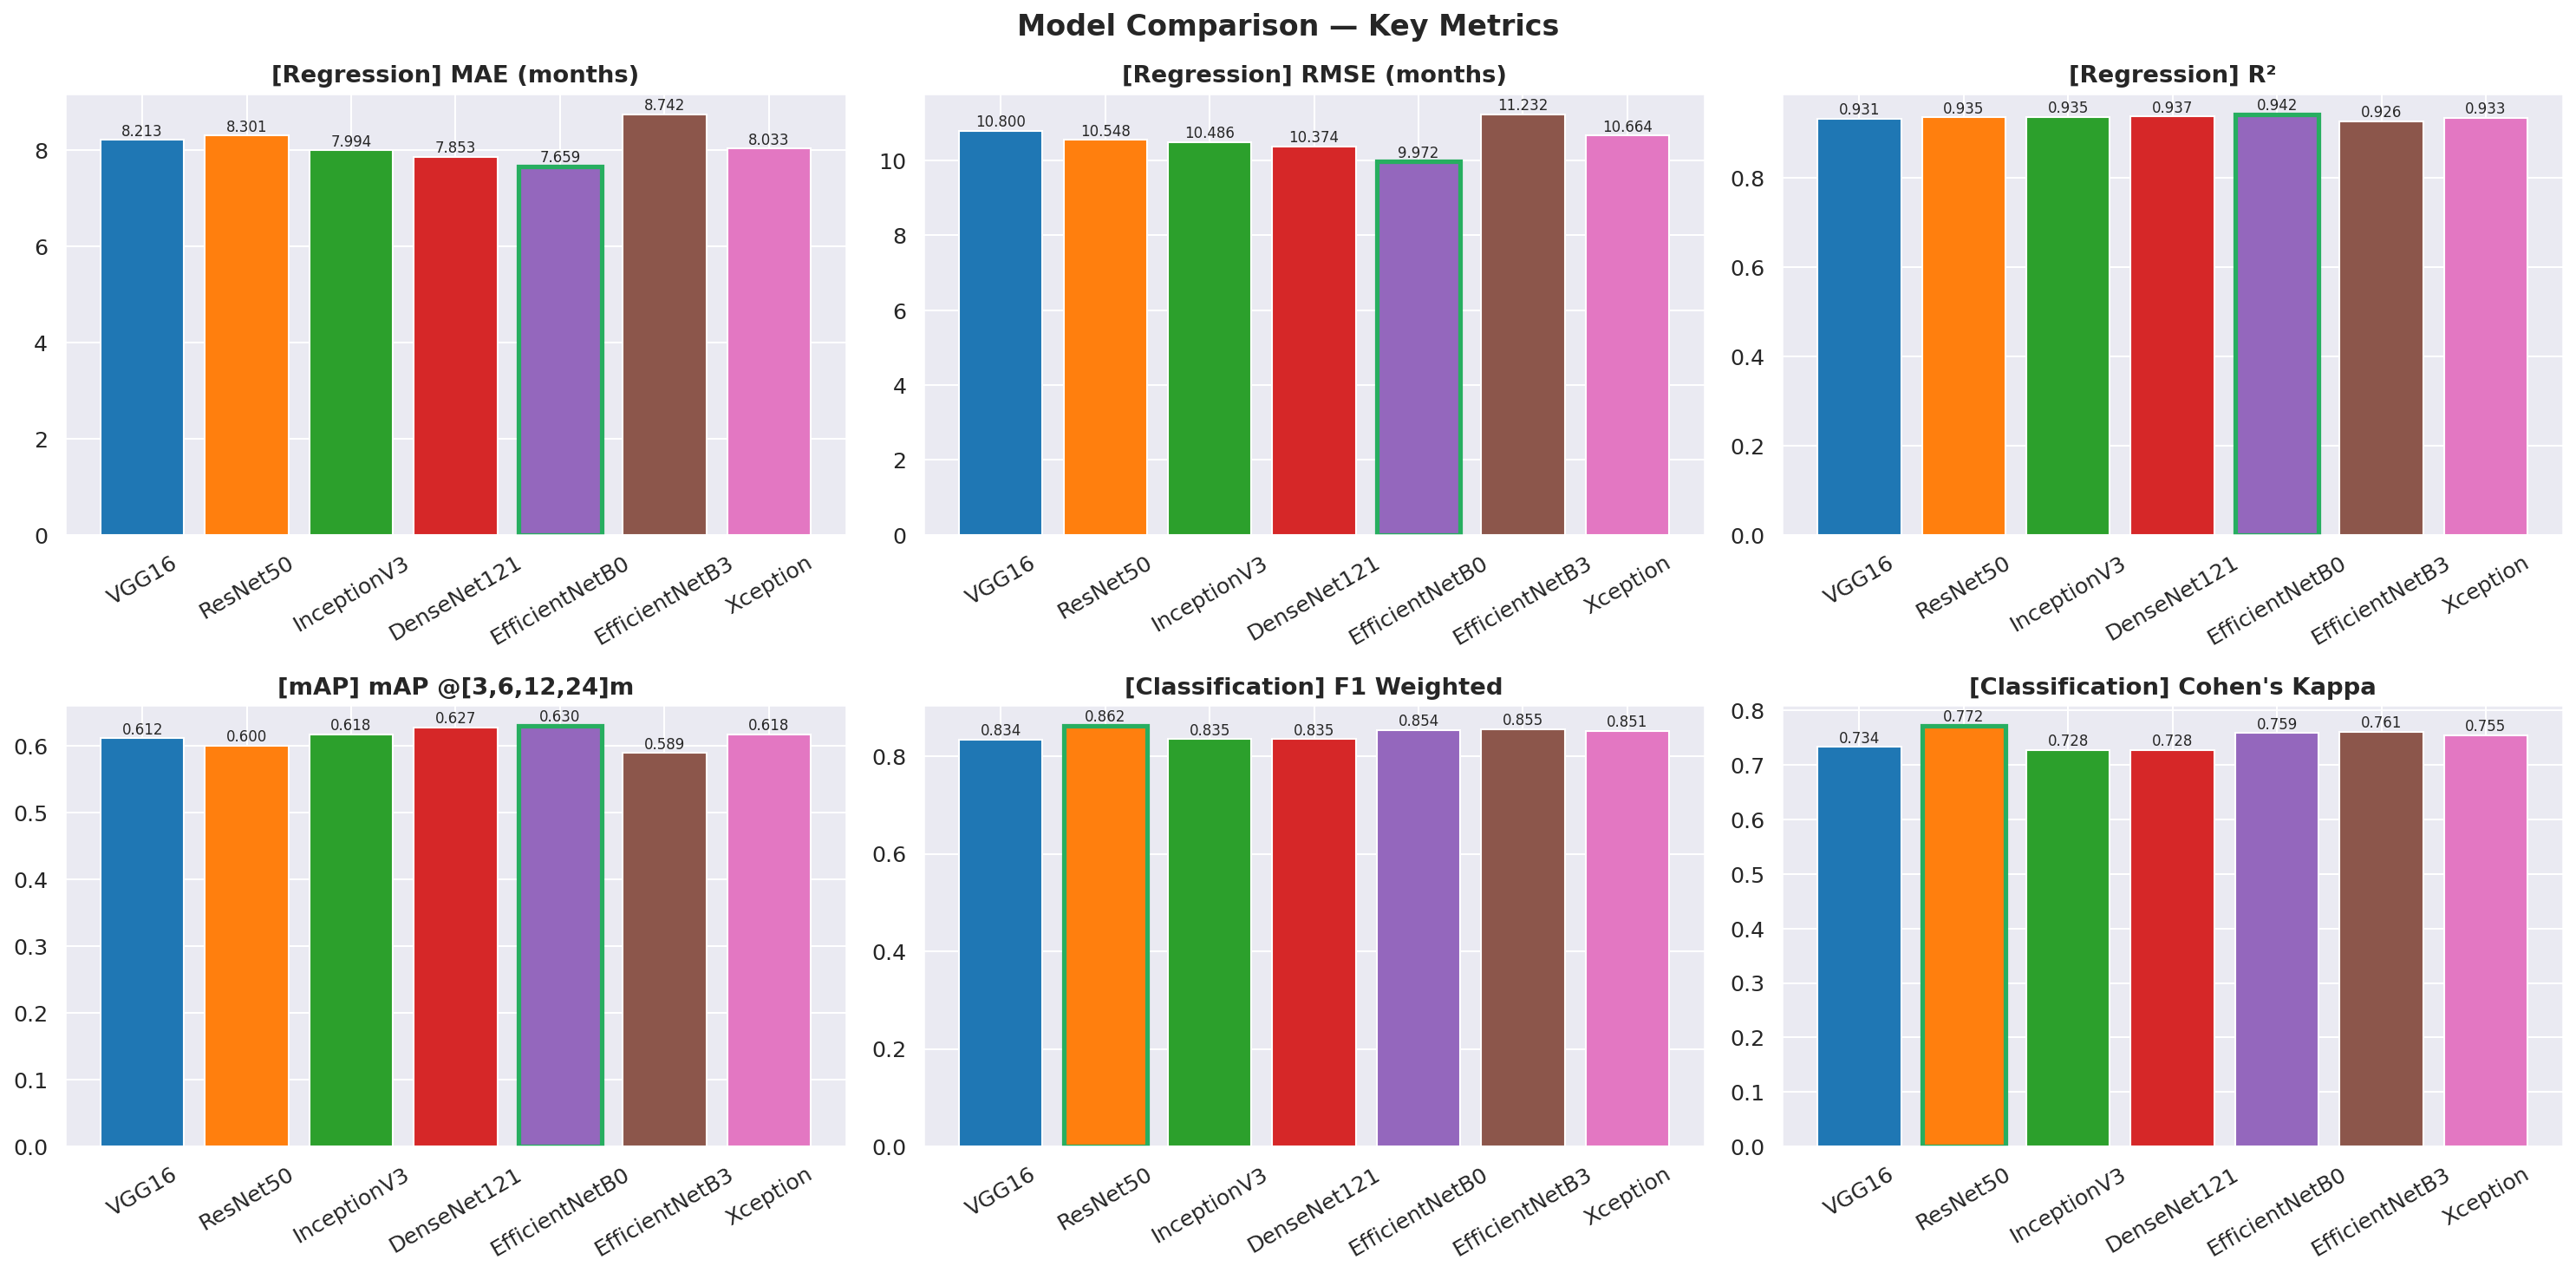


--- 08_radar_chart.png ---


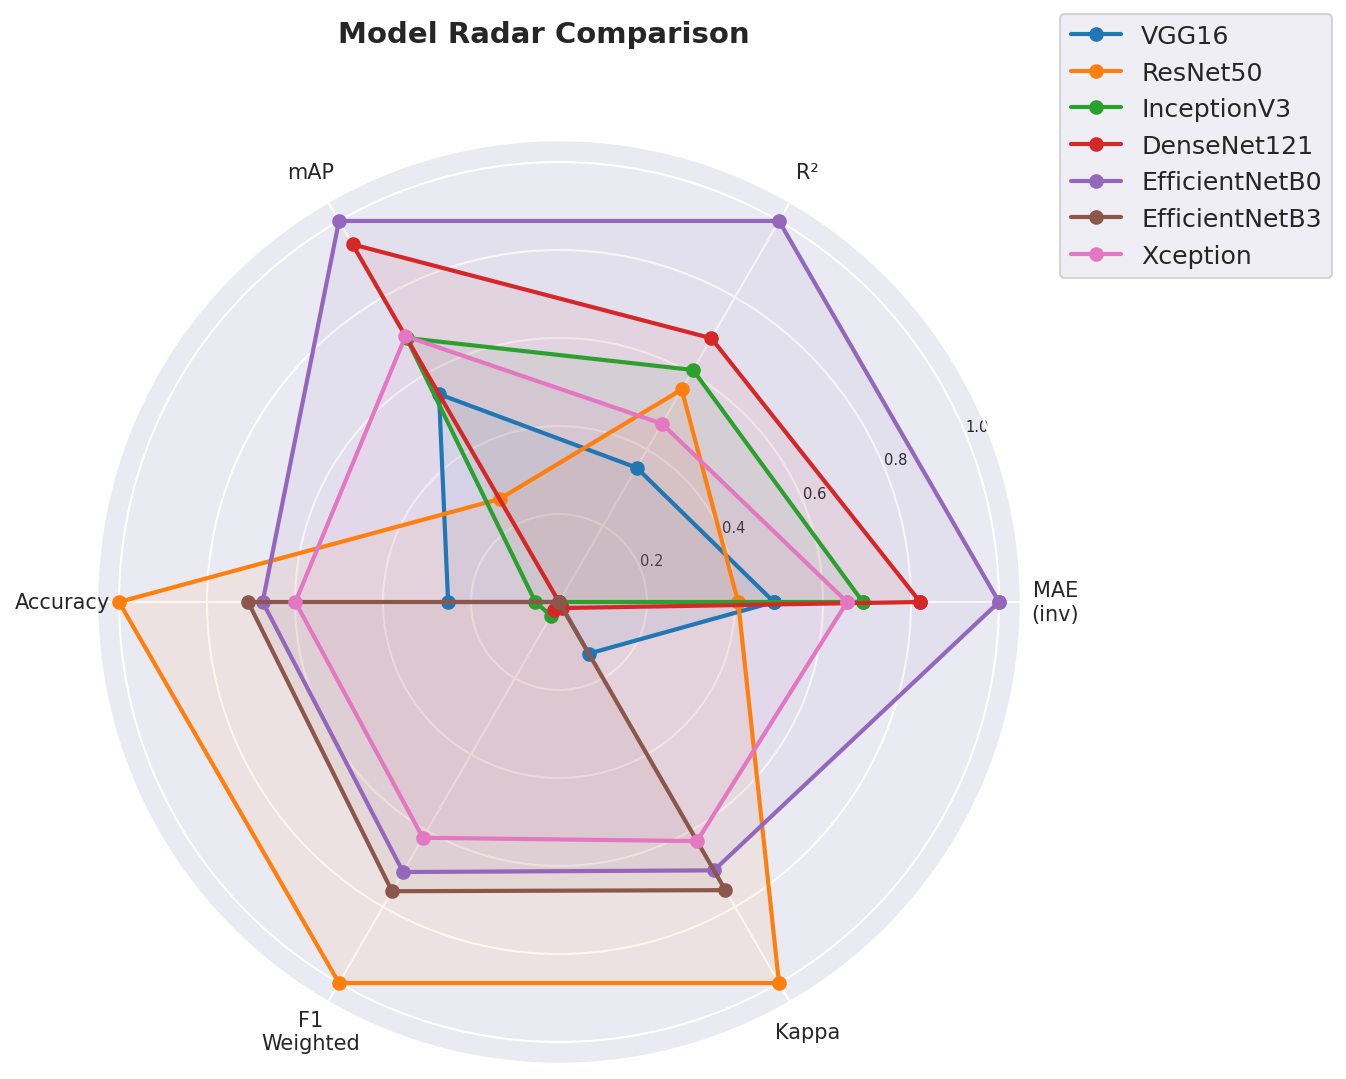


--- 09_all_models_scatter.png ---


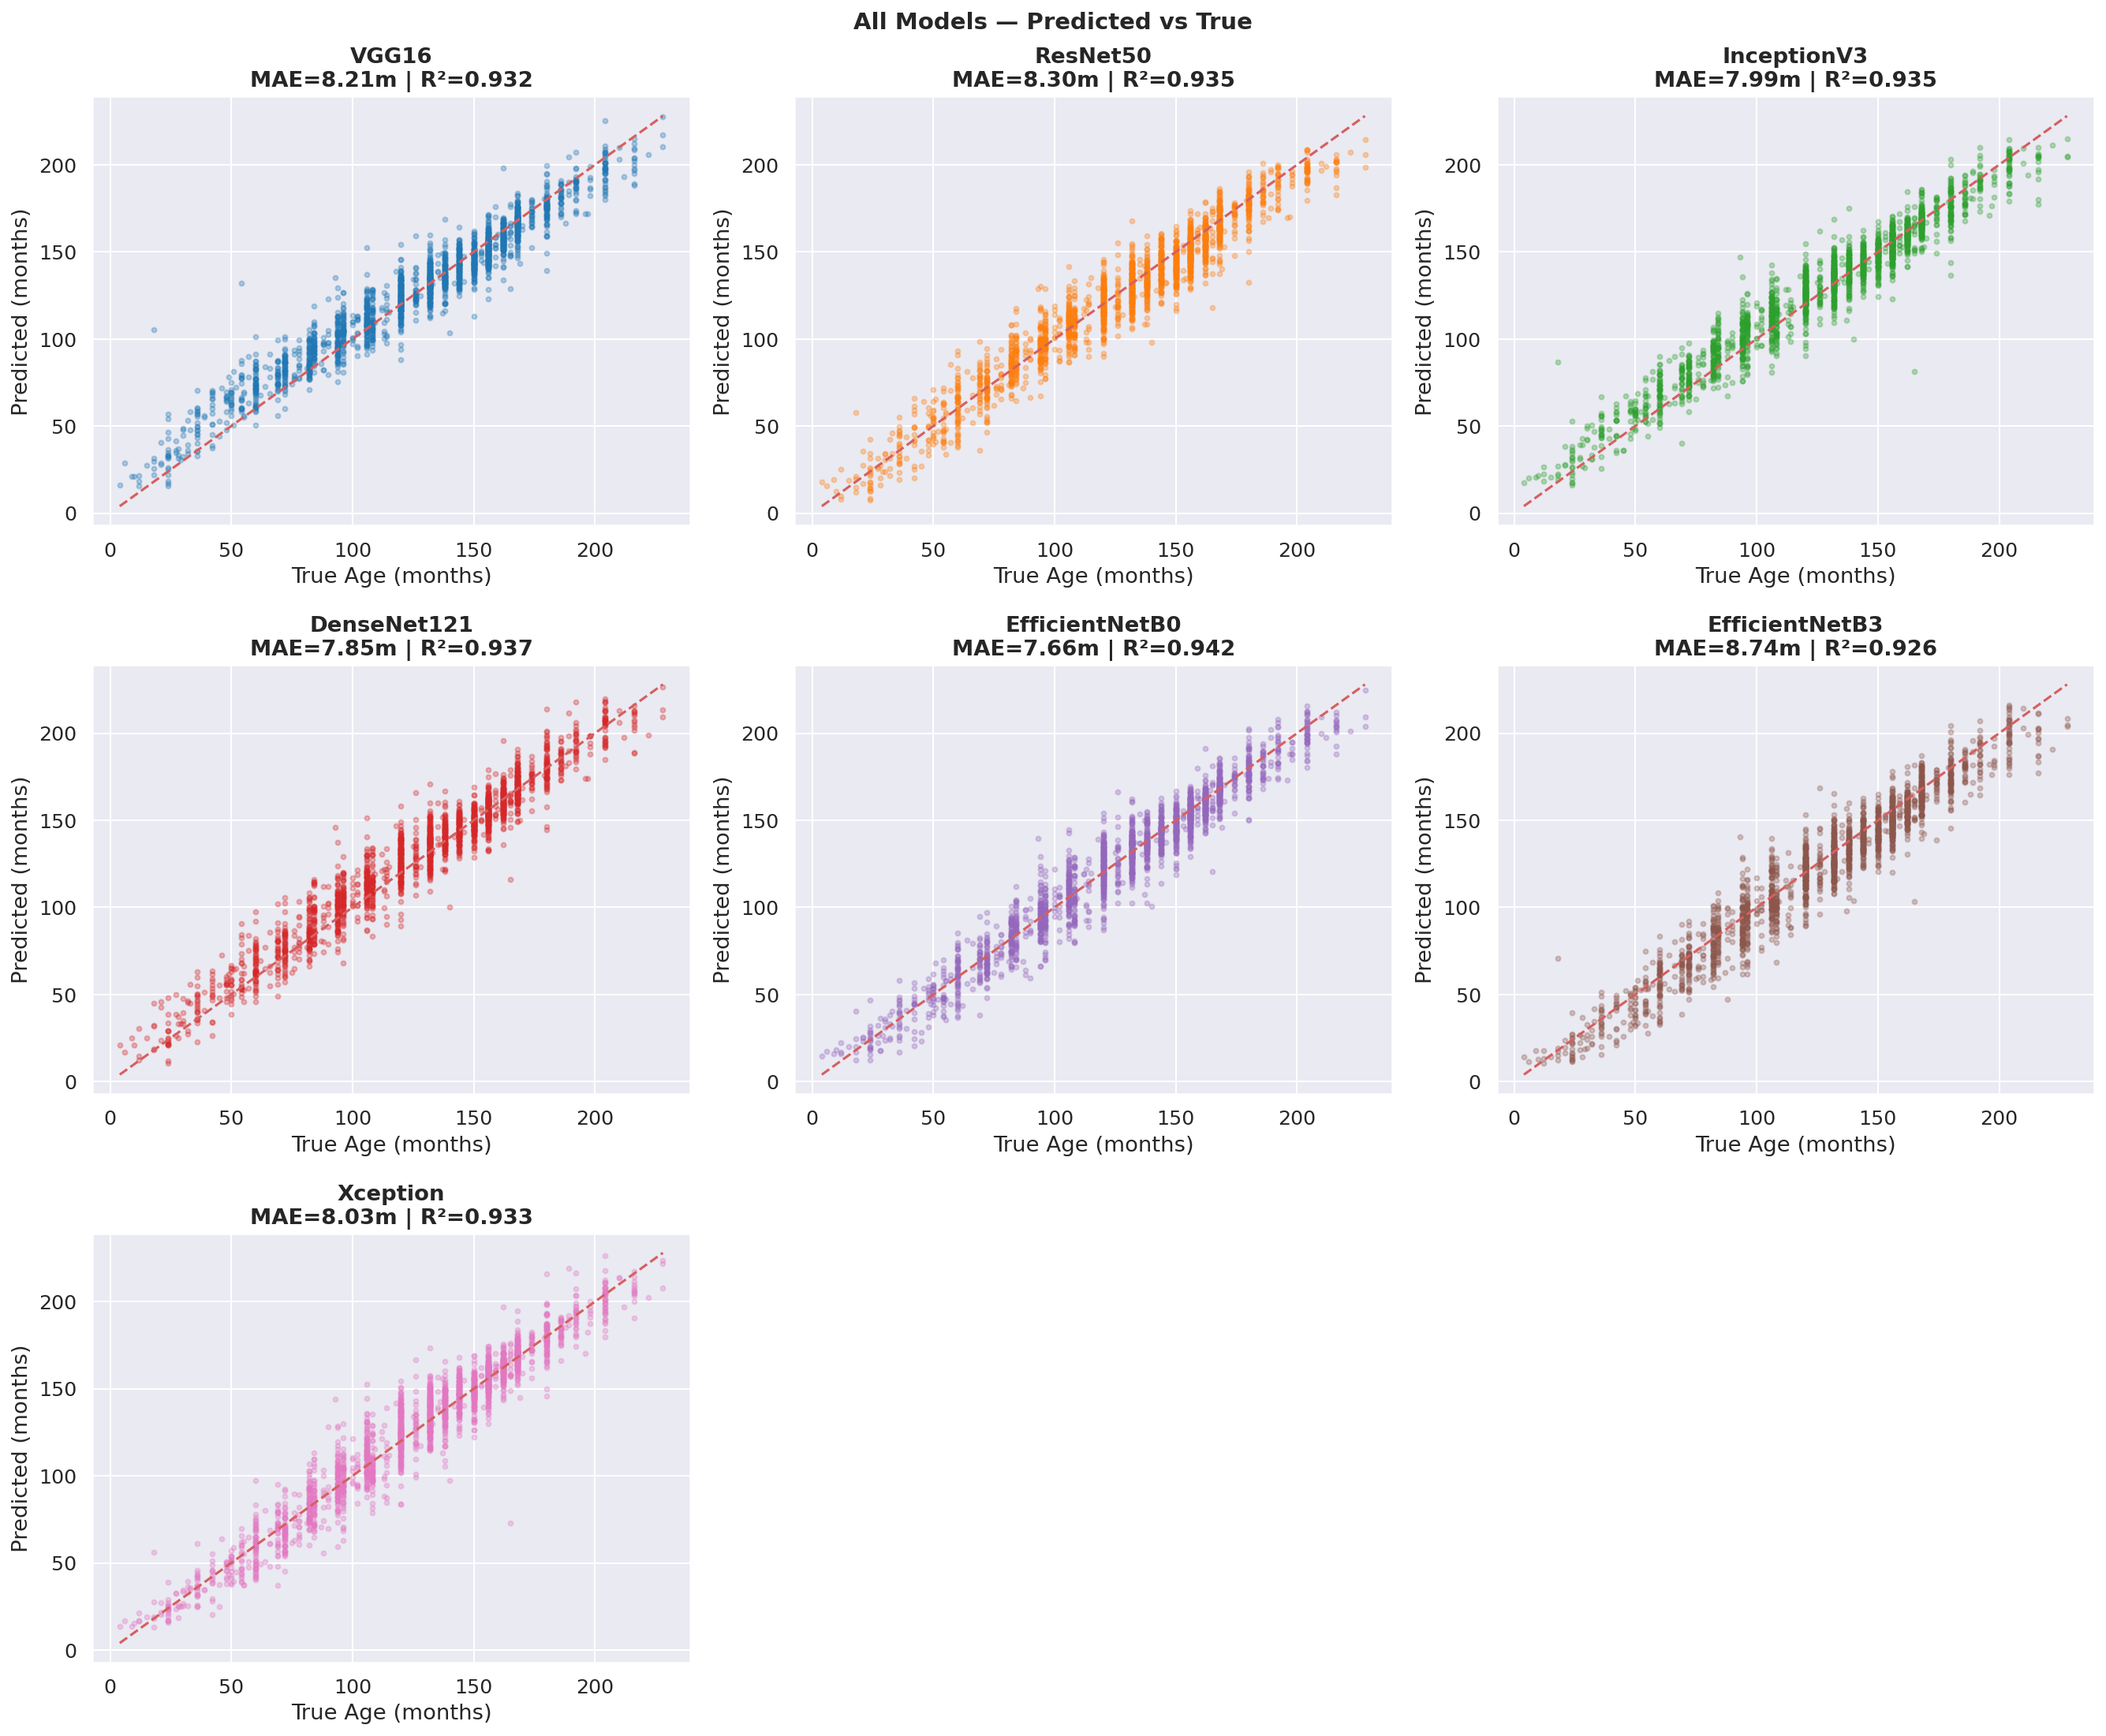


--- 10_metrics_heatmap.png ---


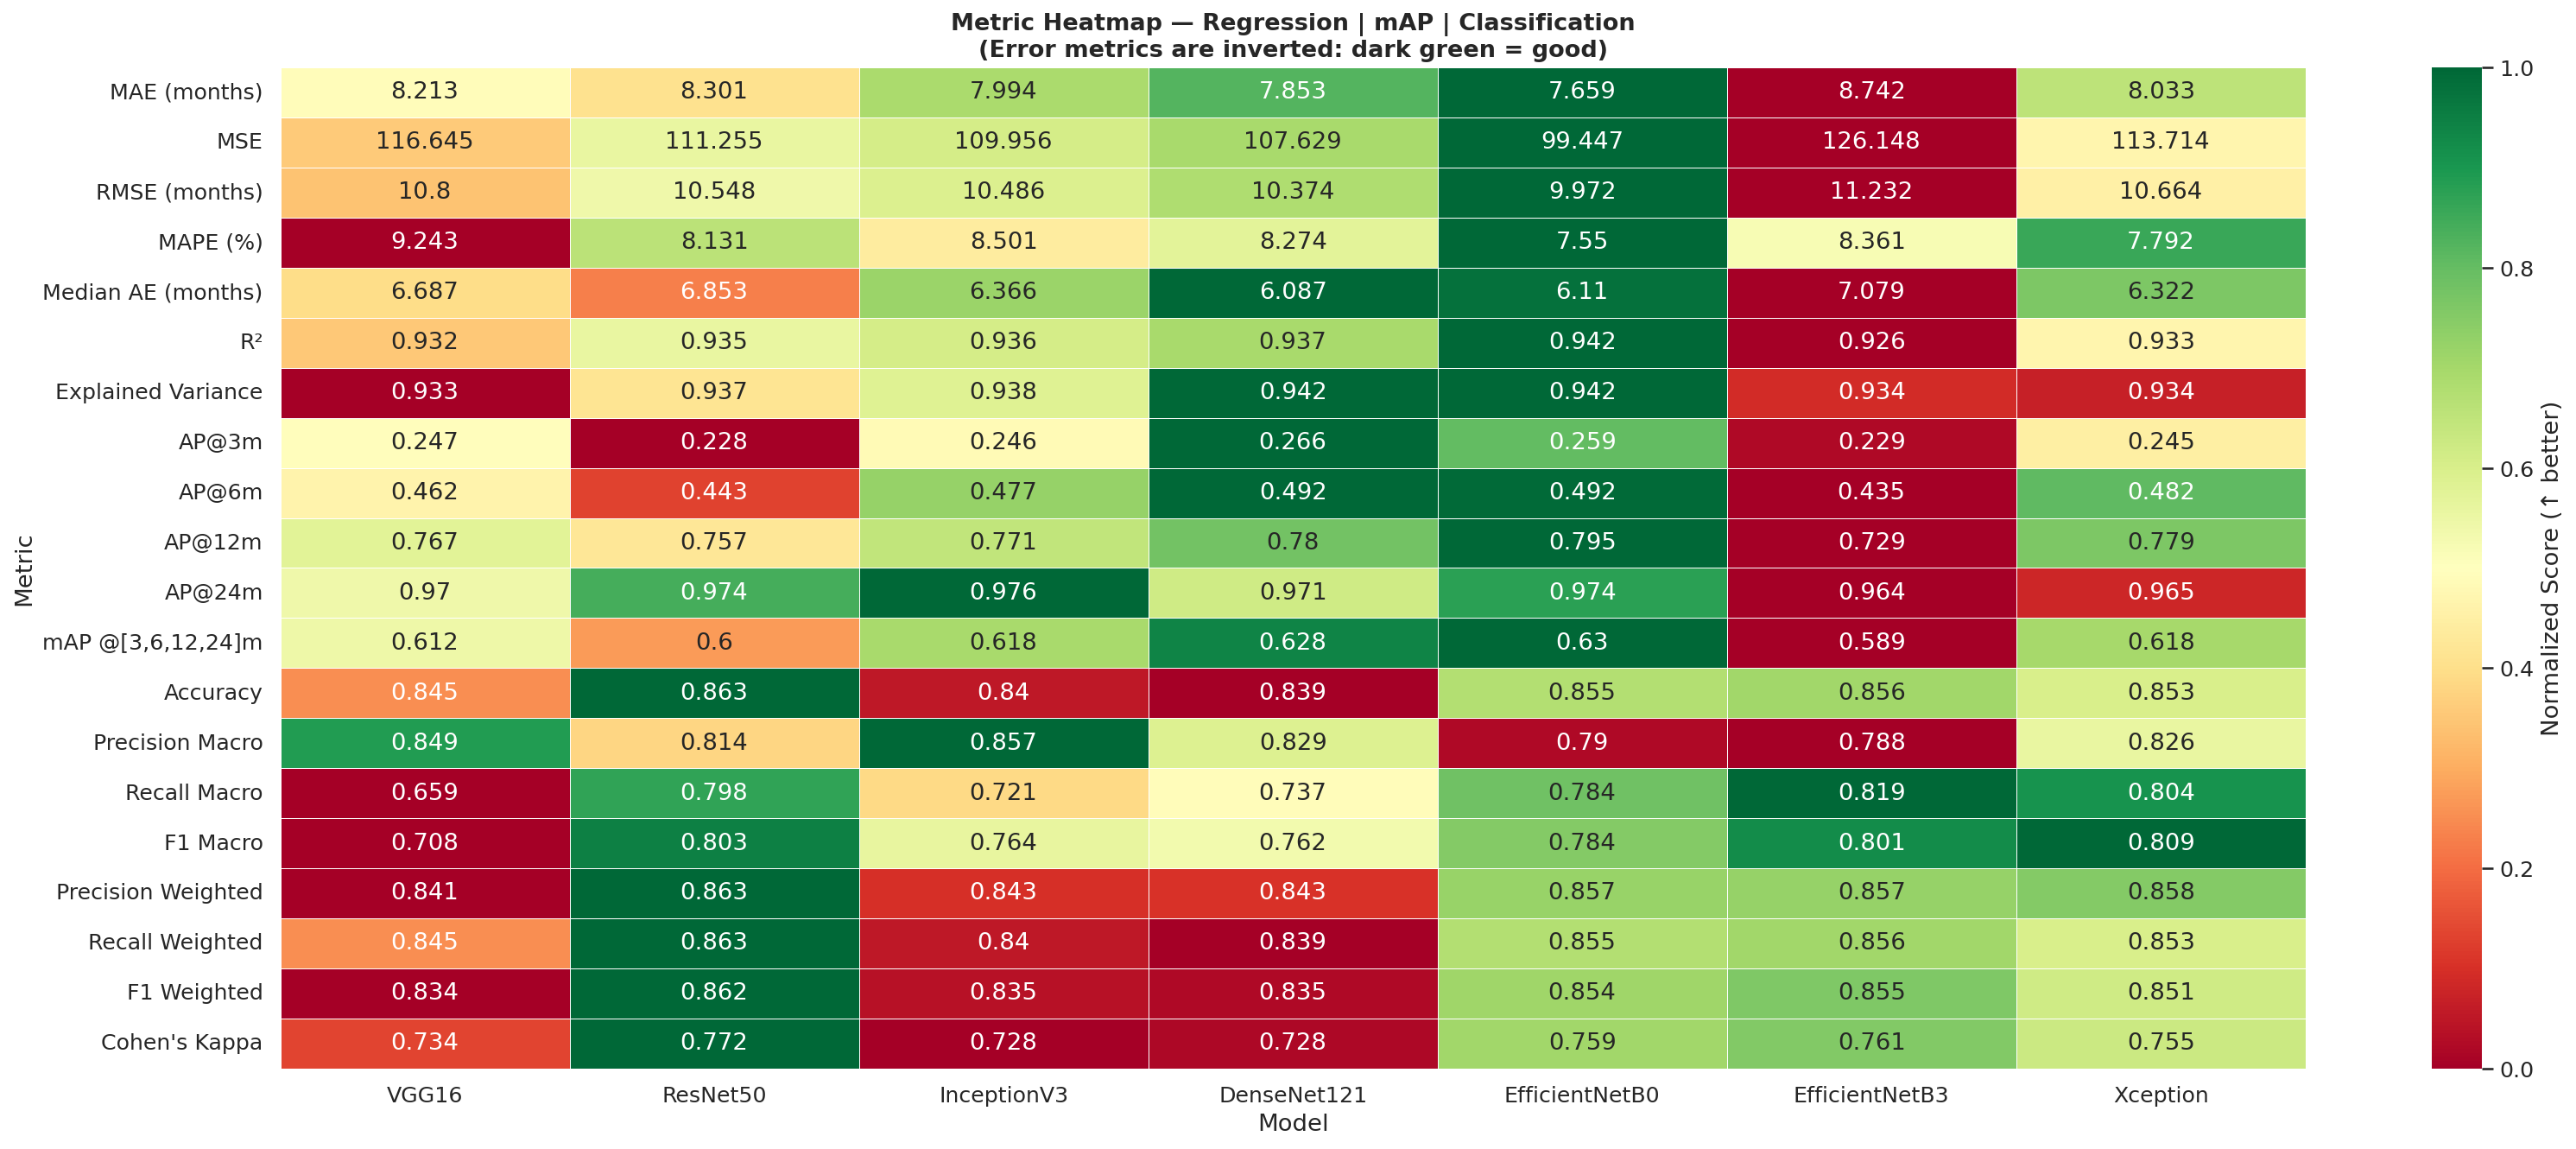


--- 11_age_group_mae.png ---


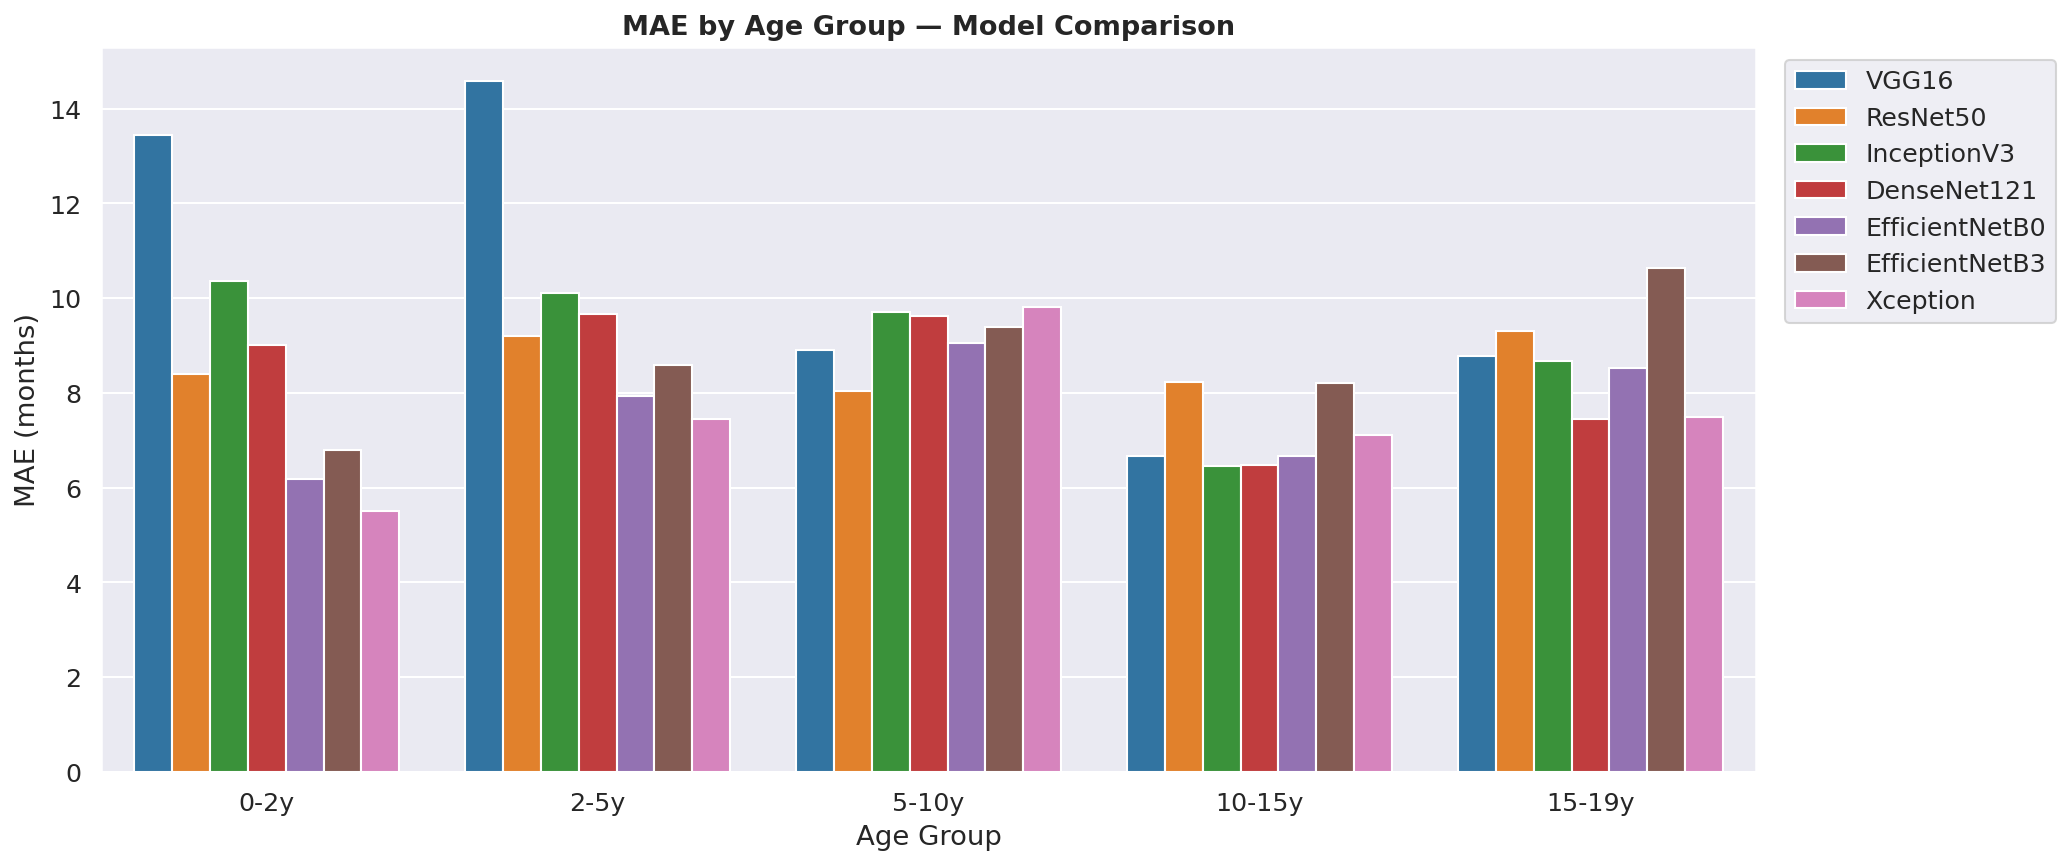


--- 12_training_histories.png ---


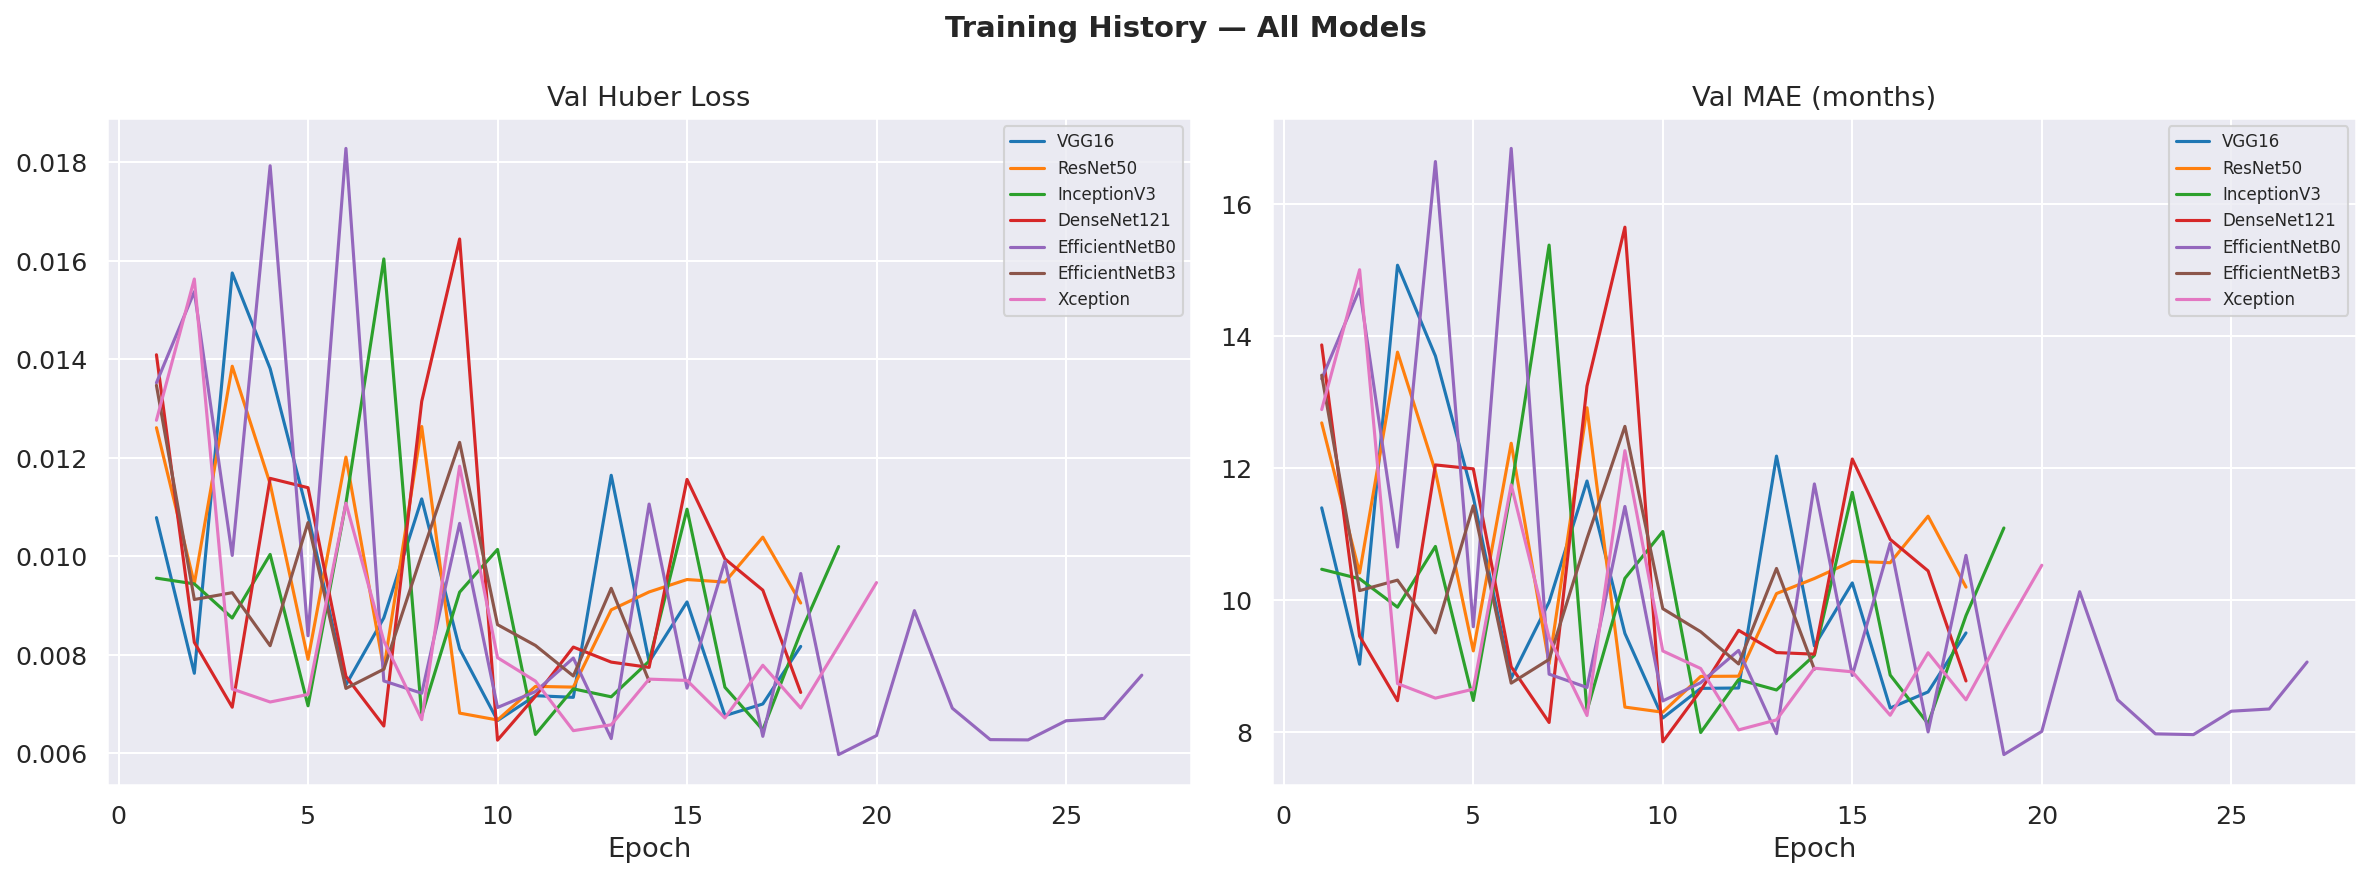


--- 13_gender_mae.png ---


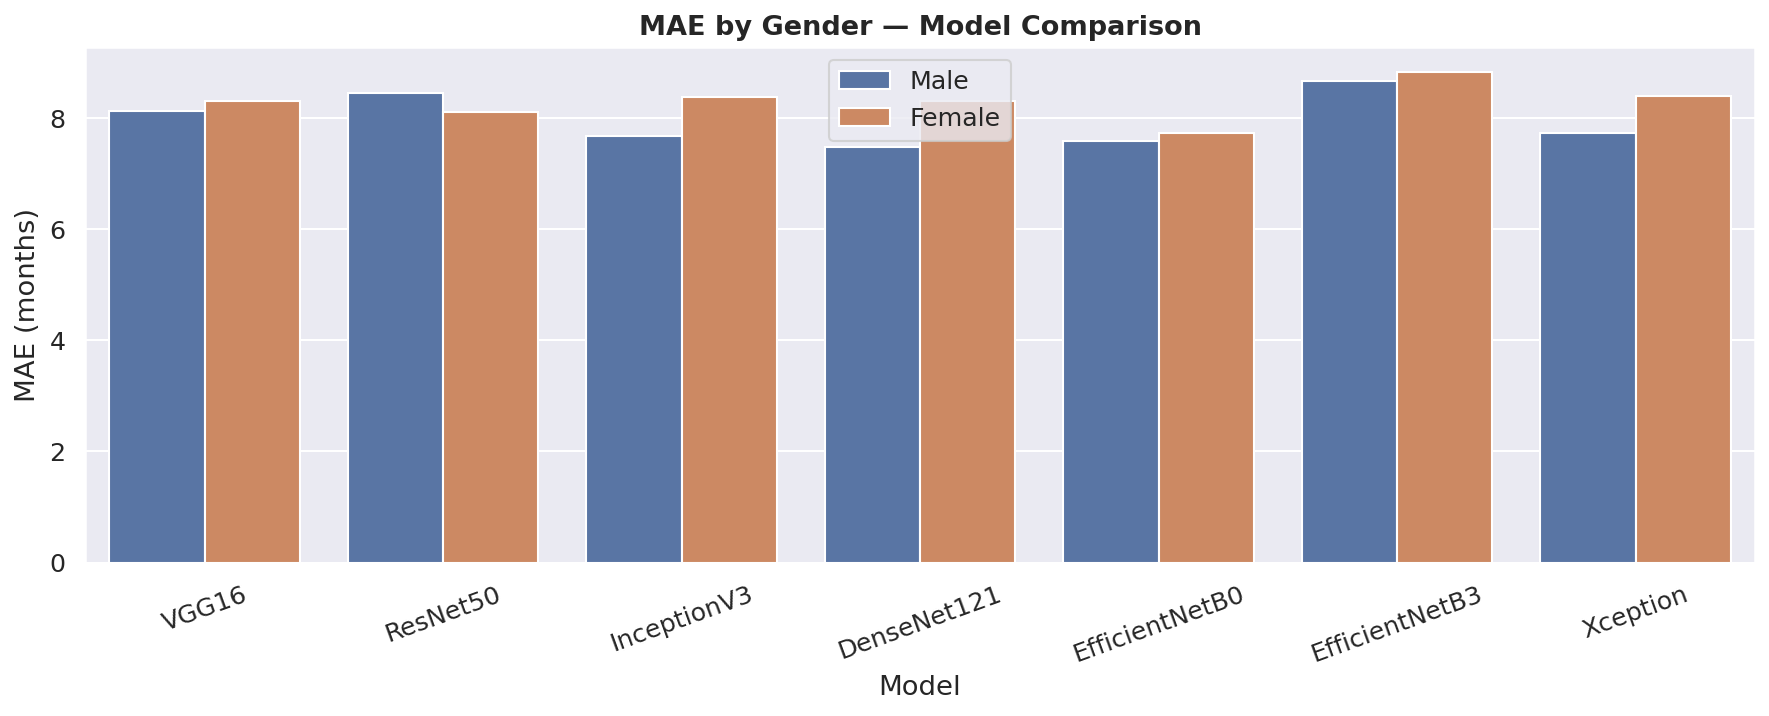

In [12]:
import os
import IPython.display as disp

eval_dir = "/kaggle/working/eval_plots"
if os.path.isdir(eval_dir):
    for f in sorted(os.listdir(eval_dir)):
        if f.endswith(".png"):
            print(f"\n--- {f} ---")
            disp.display(disp.Image(os.path.join(eval_dir, f)))
else:
    print("eval_plots directory not found. Run comprehensive_metrics.py first.")


### 3.3 EDA Plots



--- 00_summary_dashboard.png ---


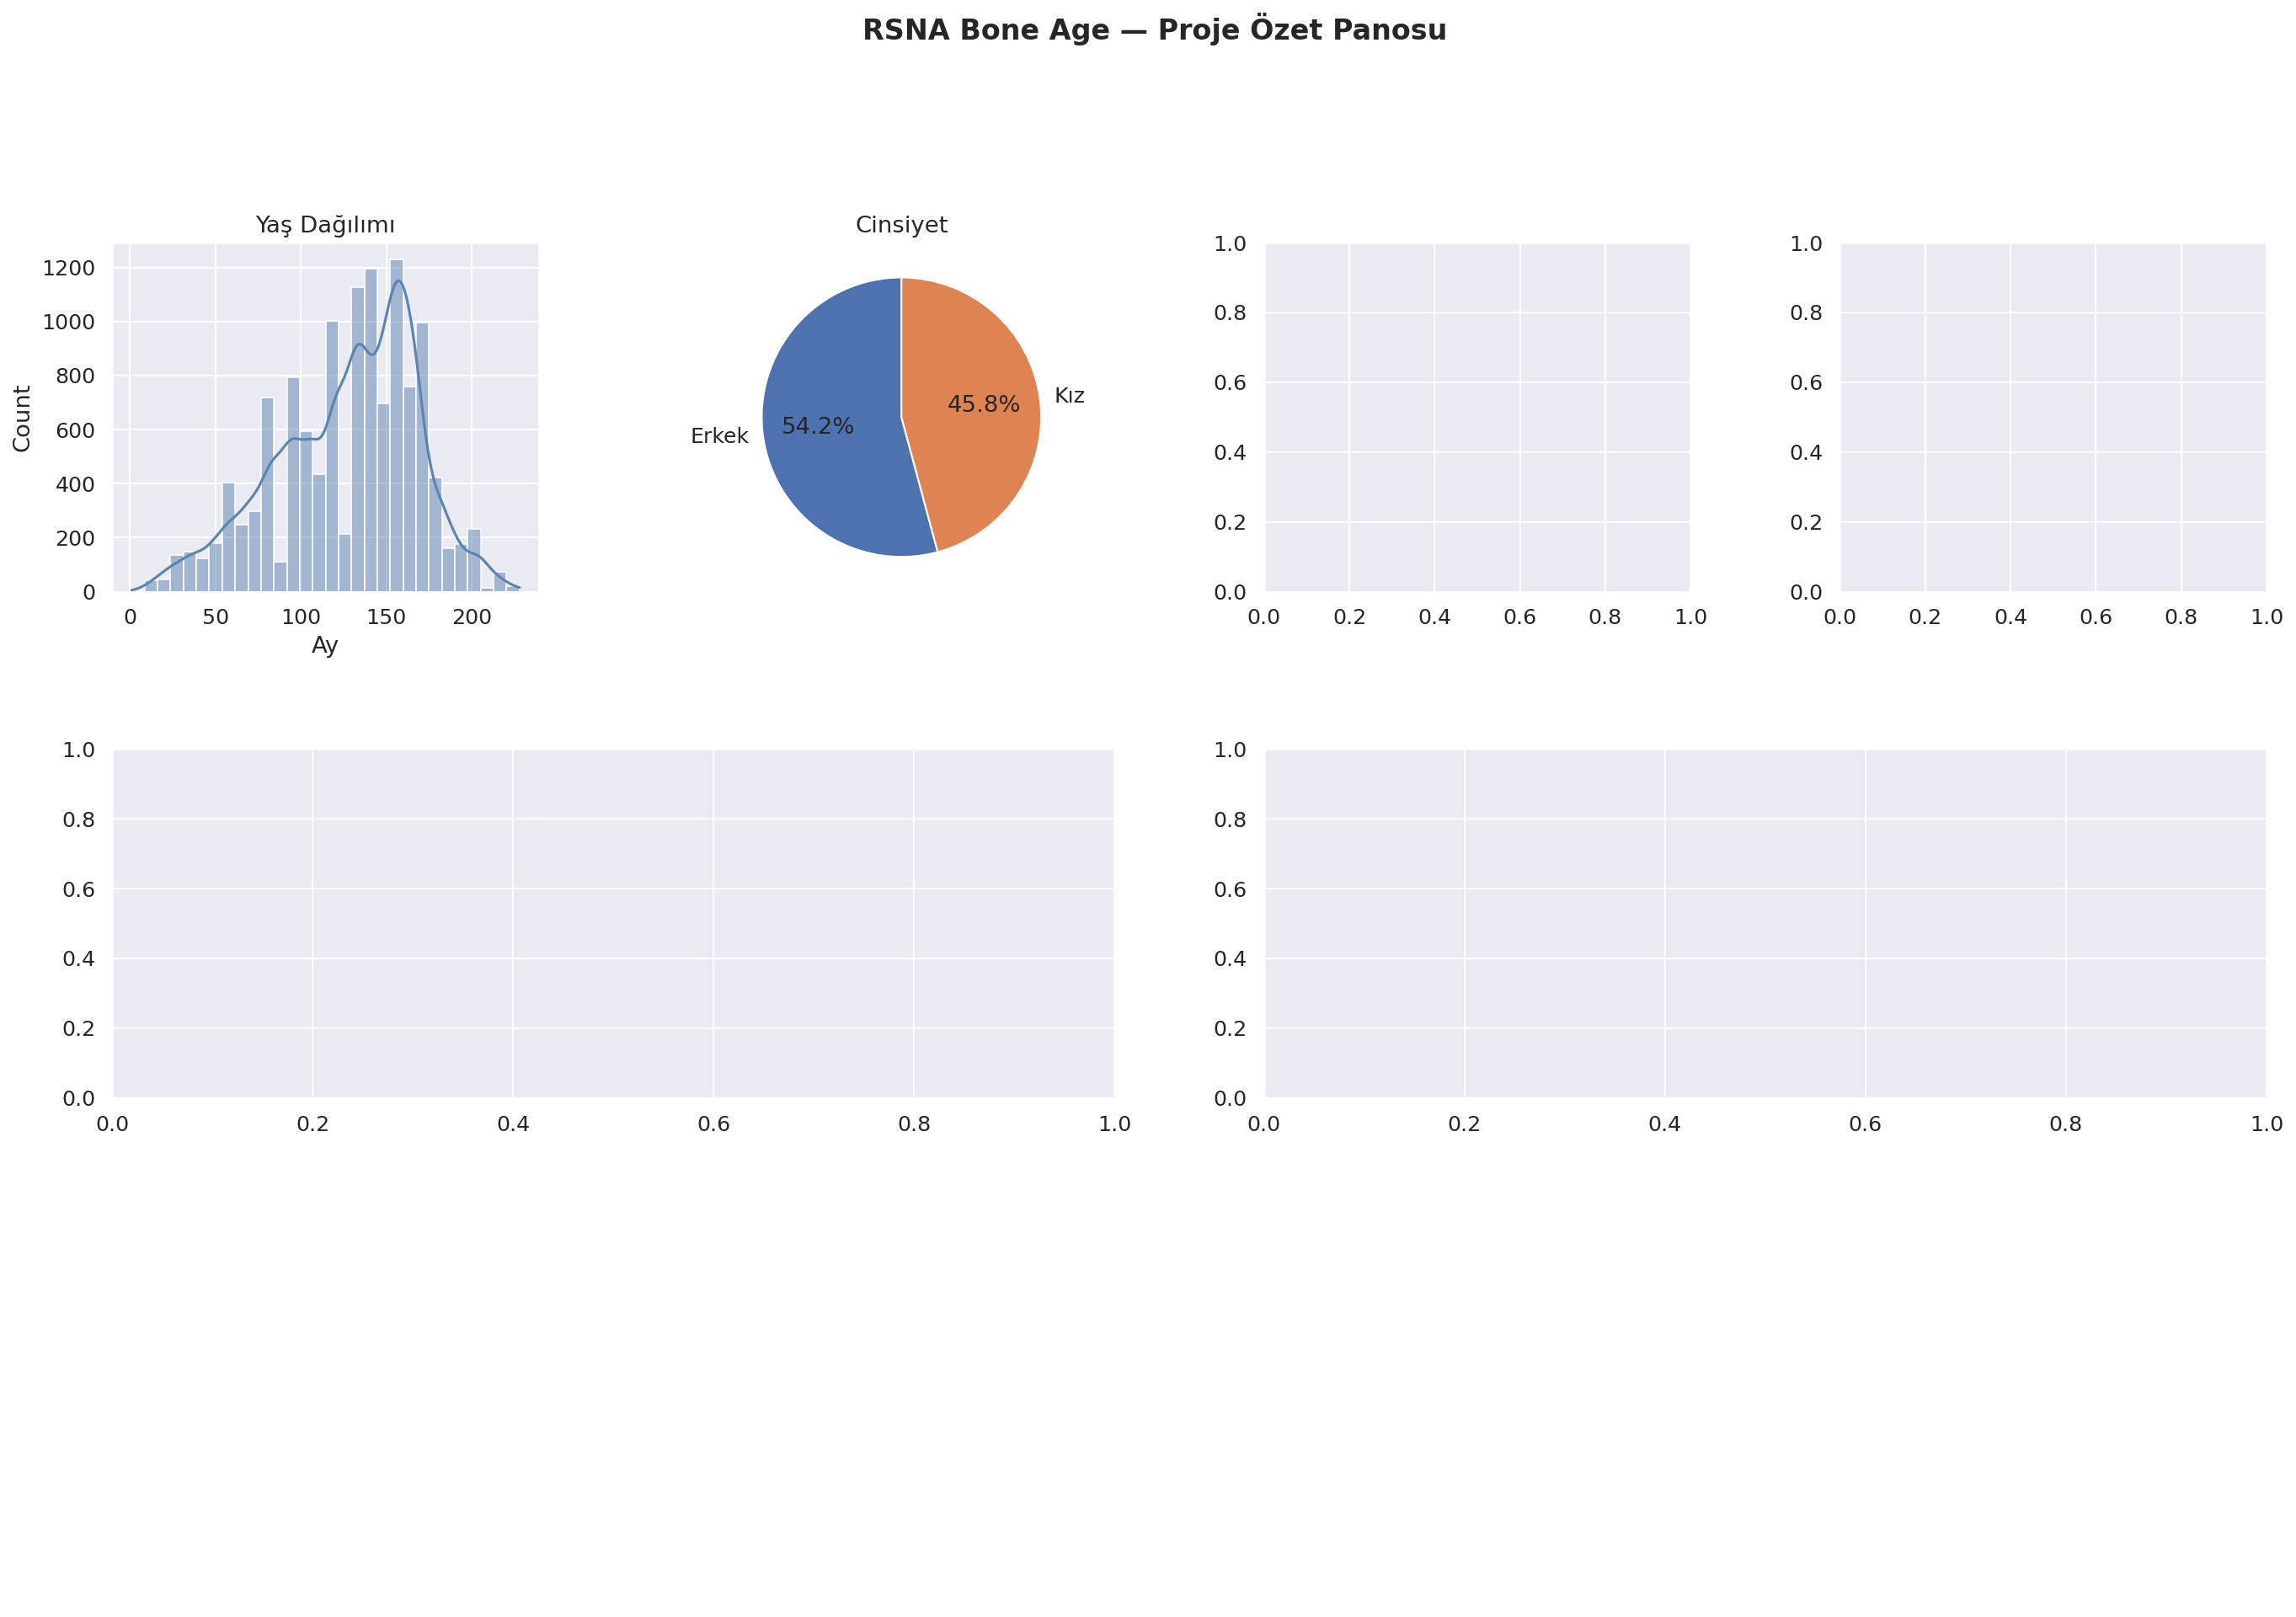


--- 01_eda_metadata.png ---


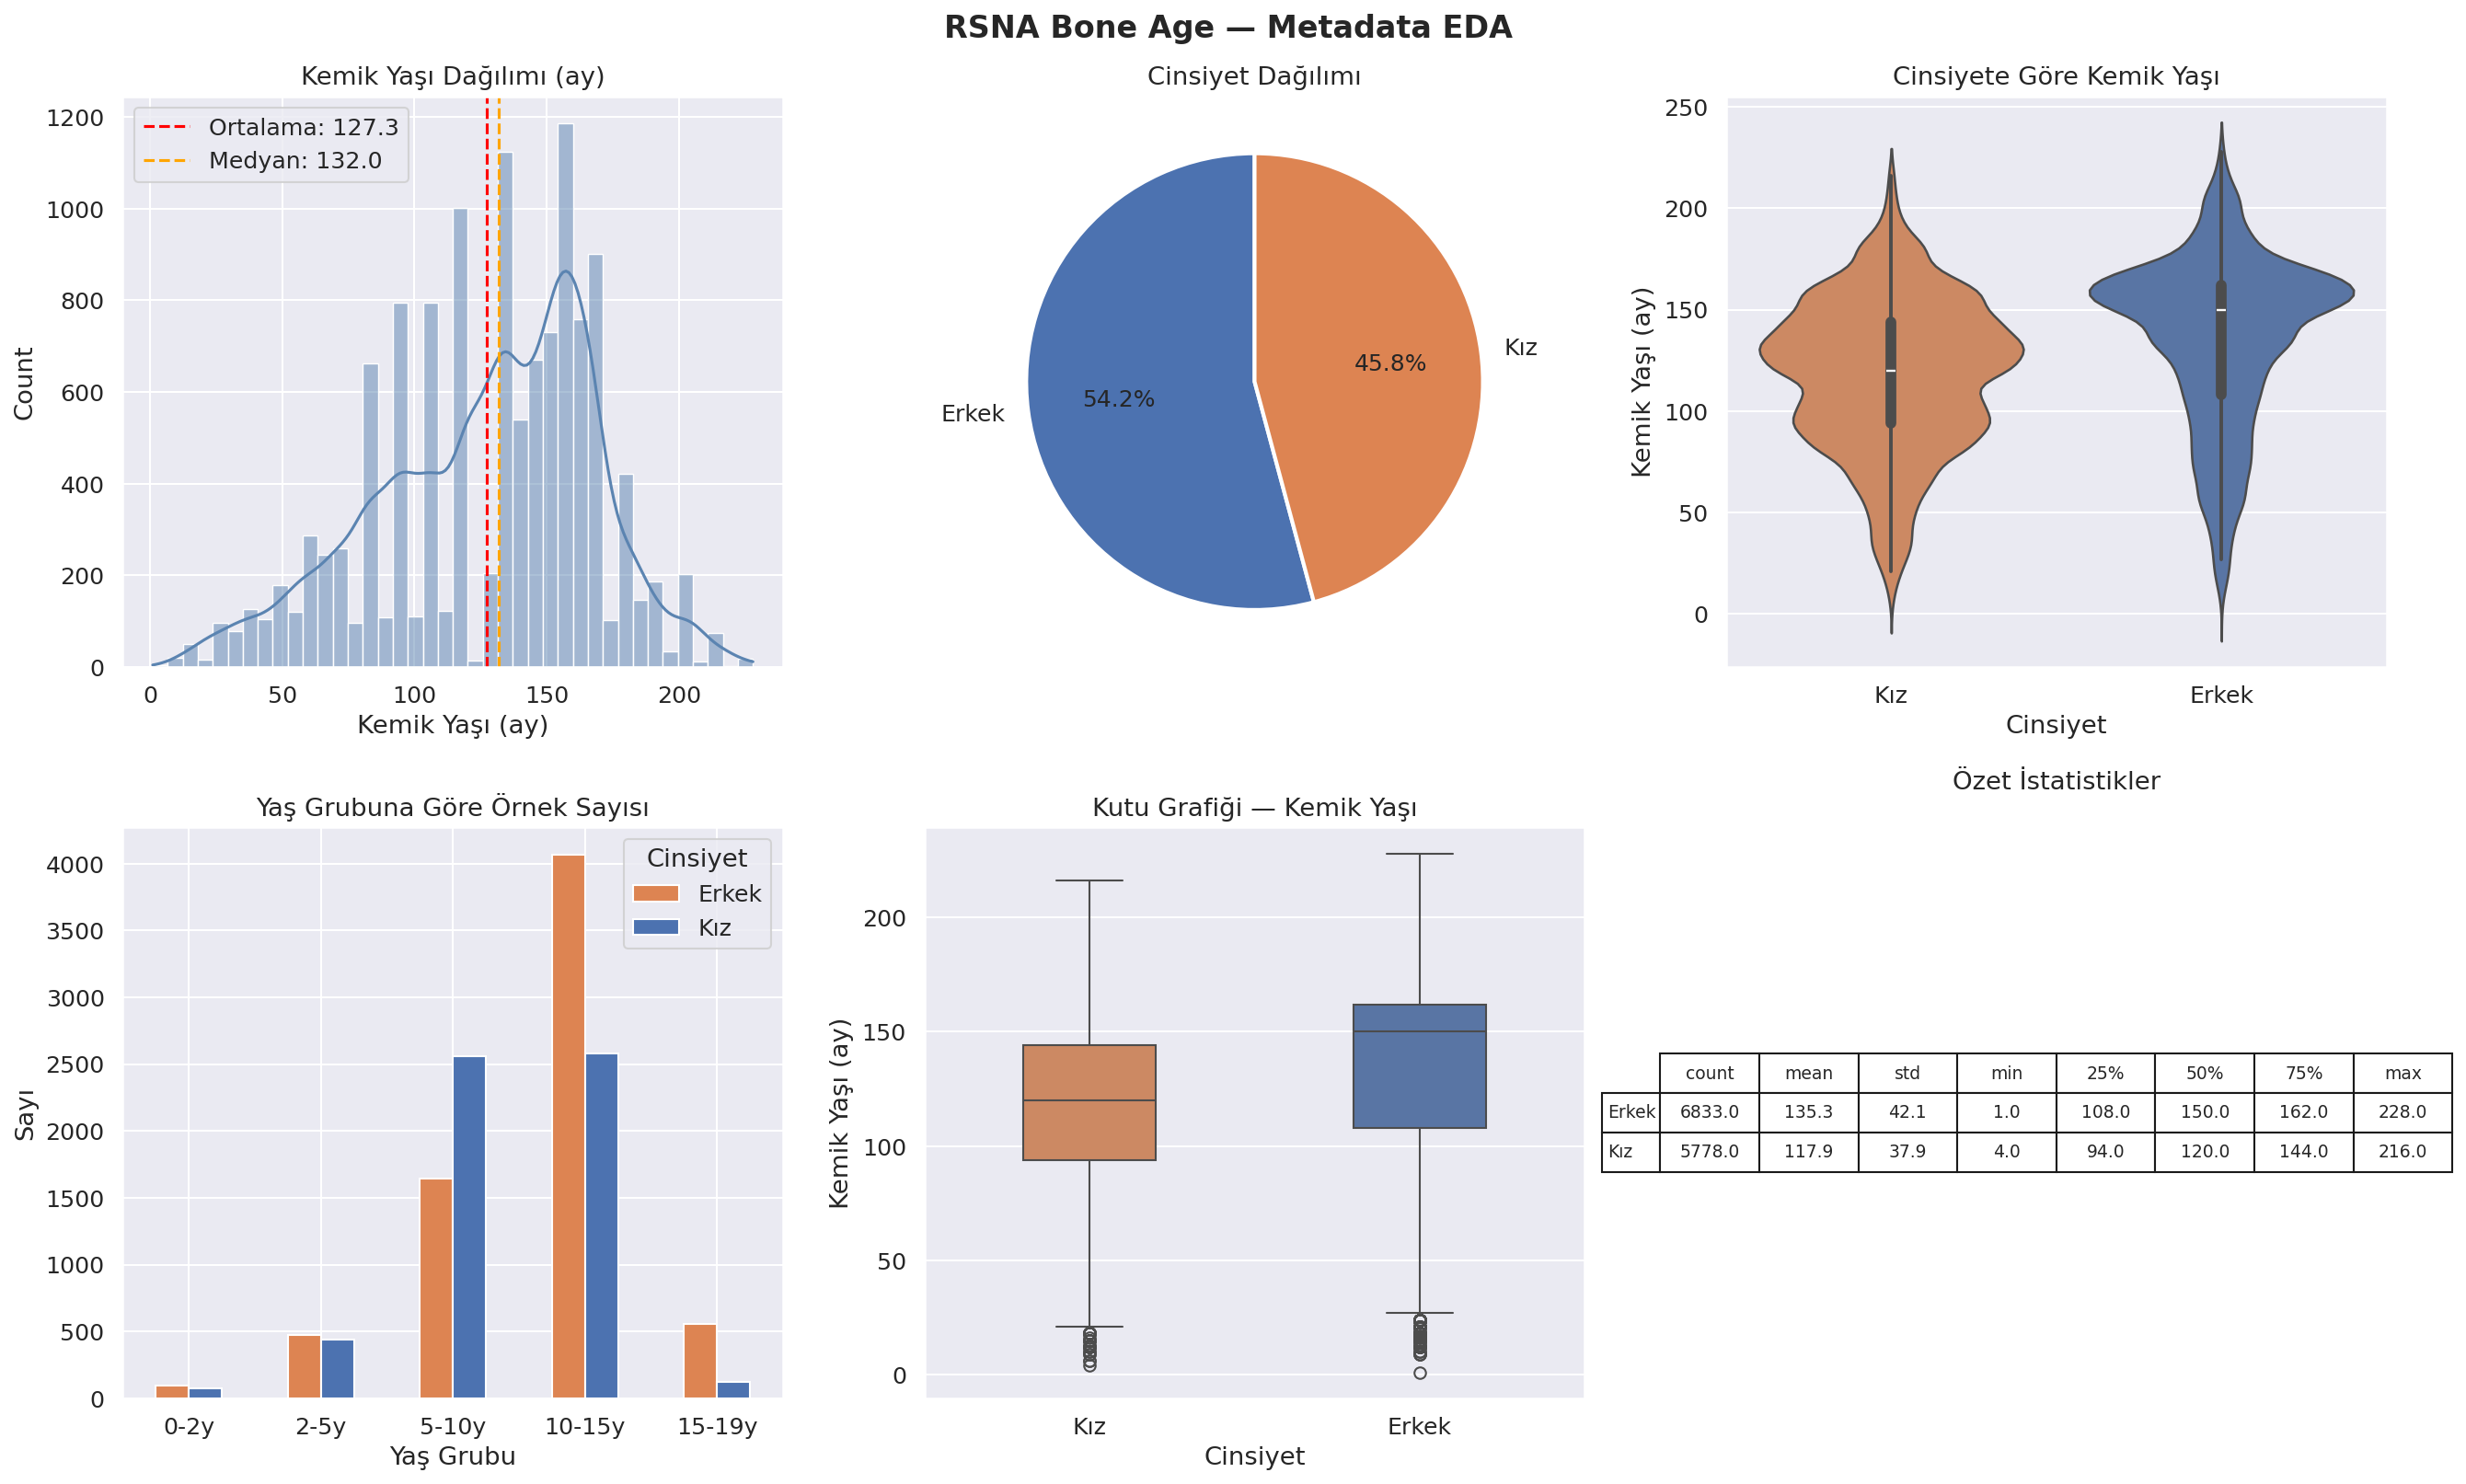


--- 02_eda_images_clahe.png ---


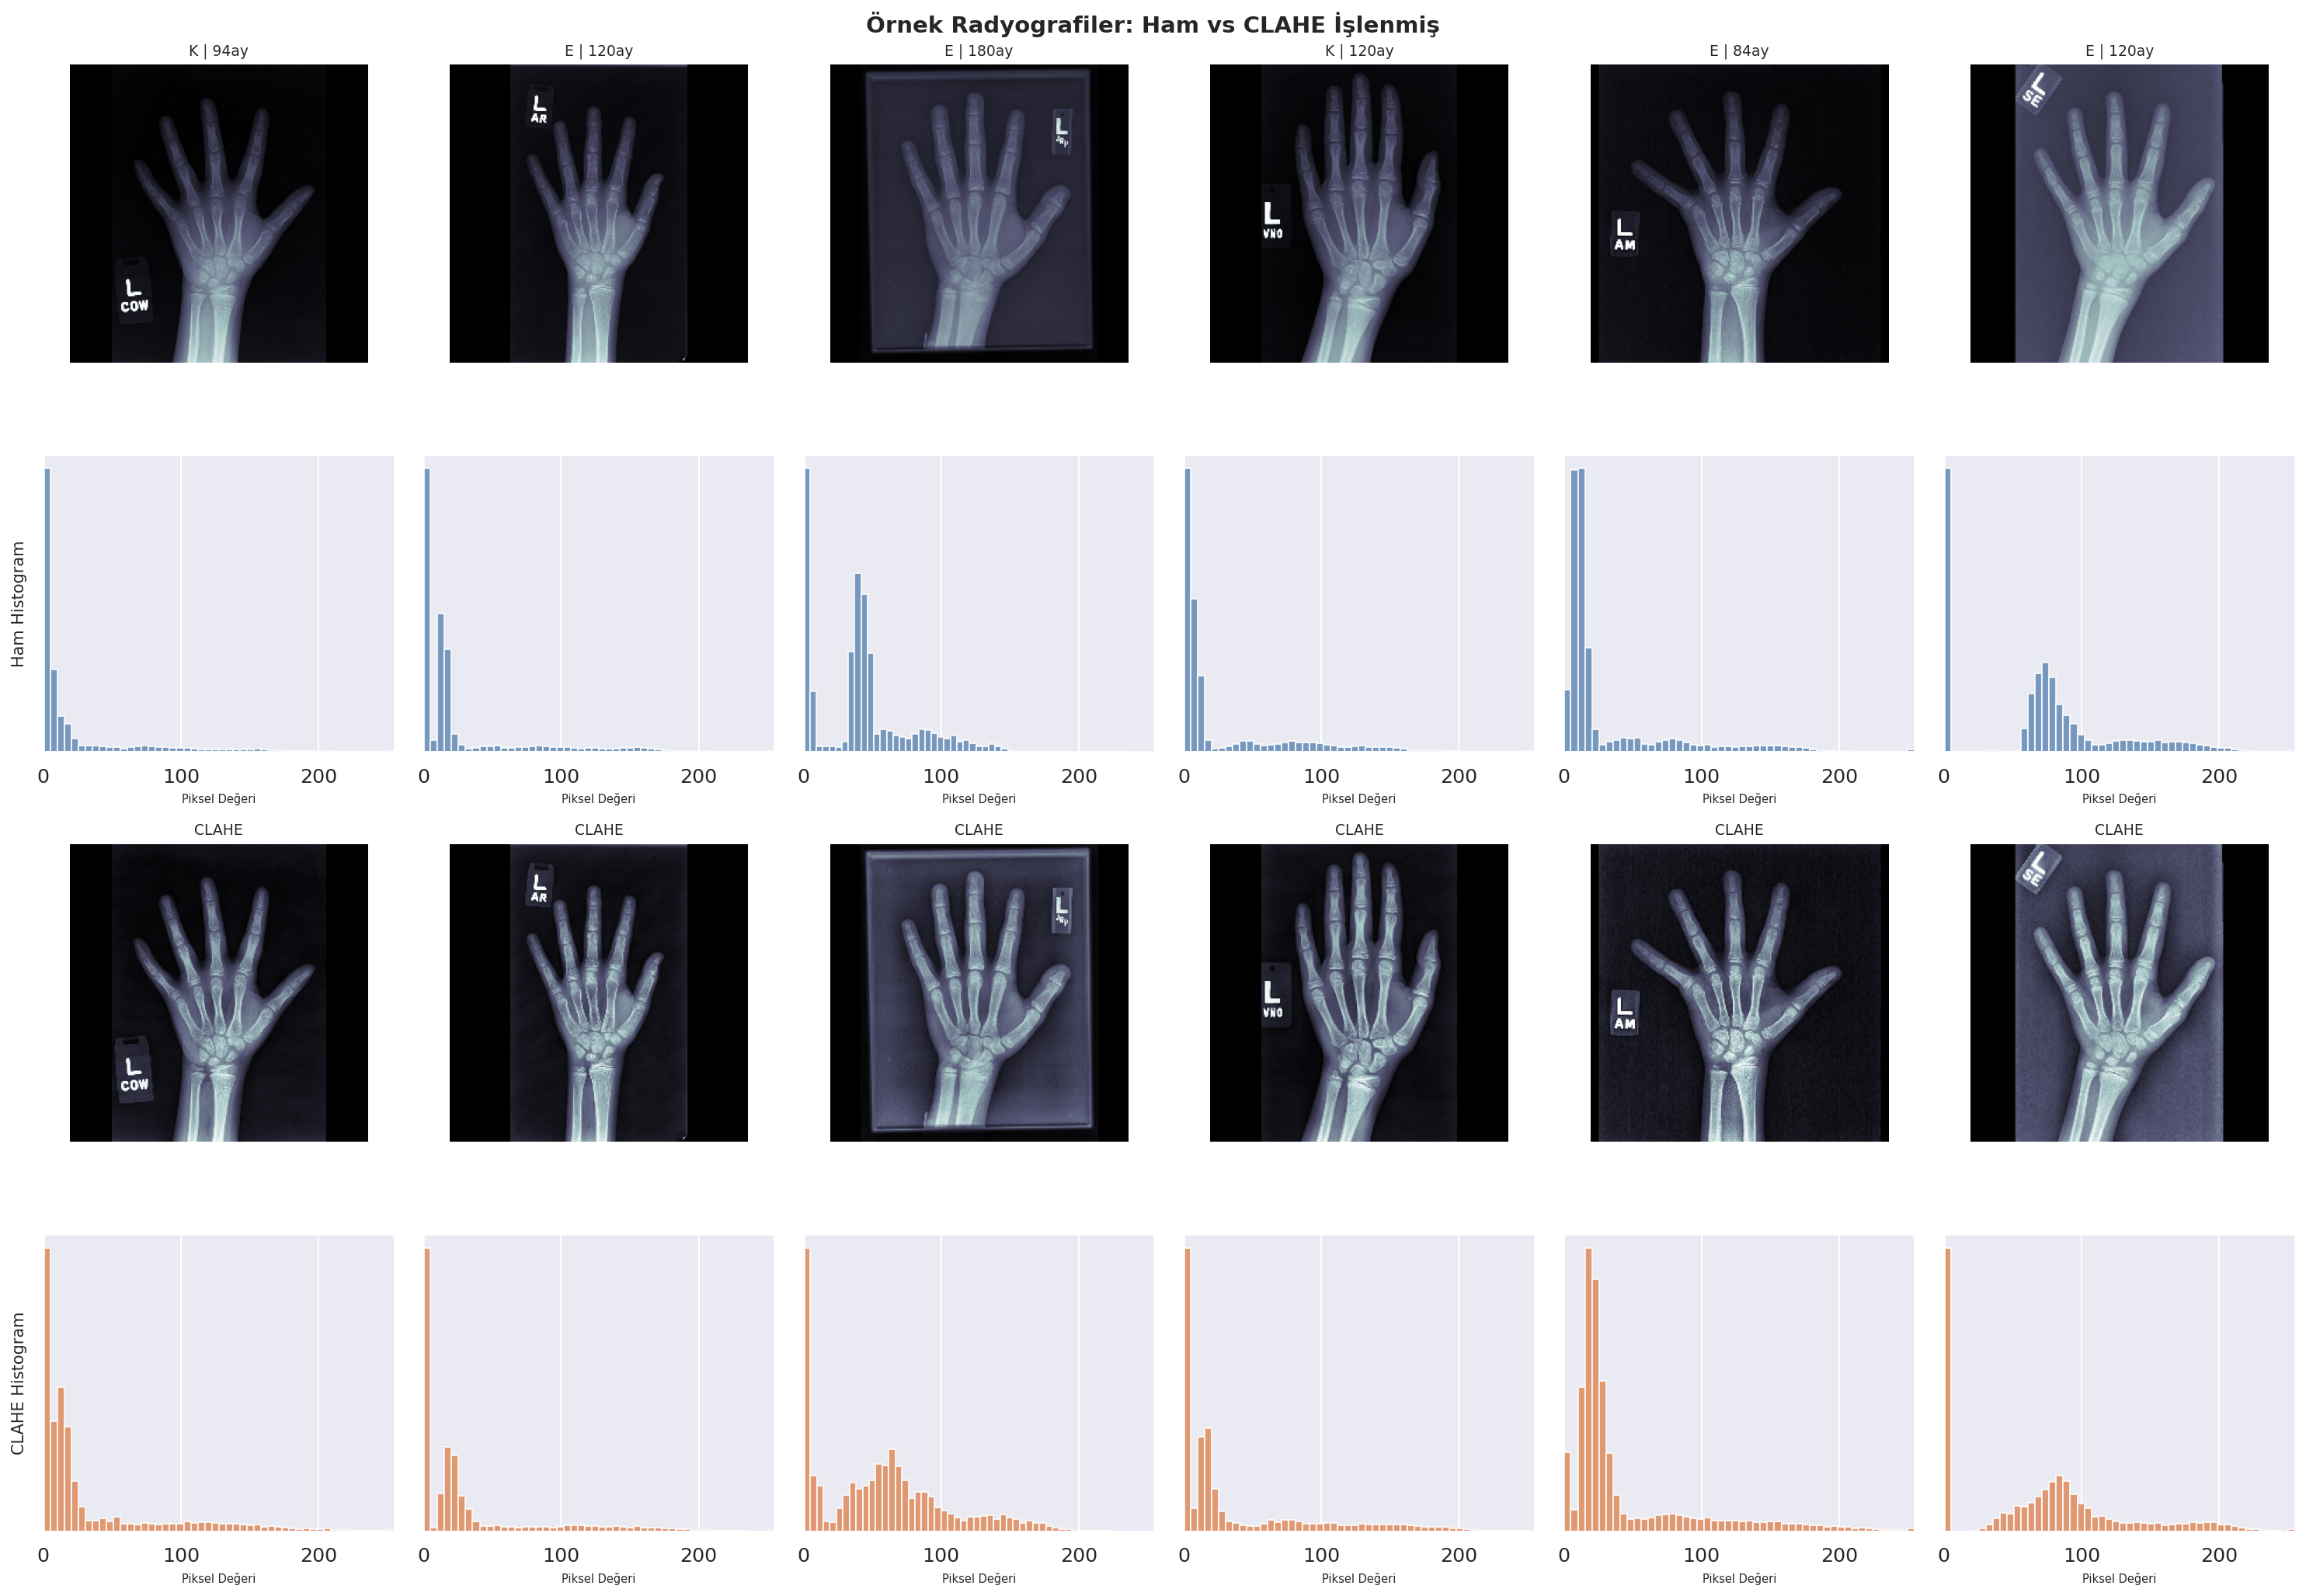


--- 03_eda_image_stats.png ---


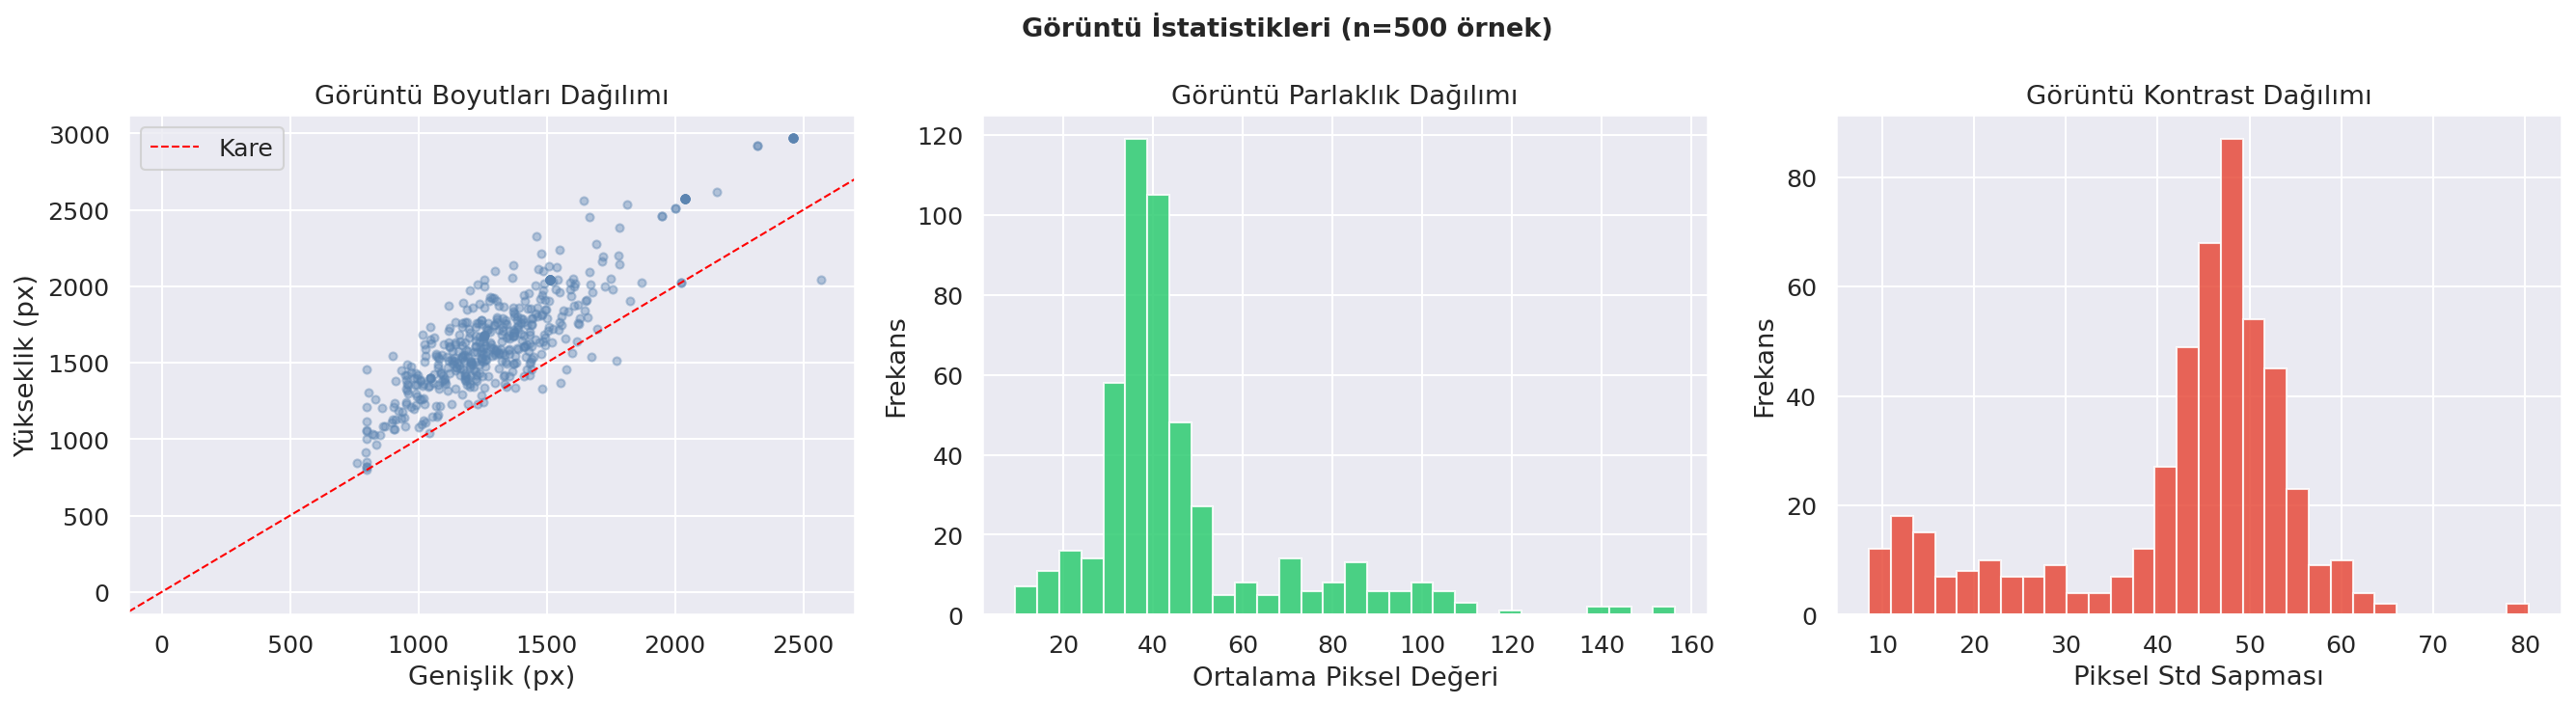

In [13]:
import os
import IPython.display as disp

plots_dir = "/kaggle/input/datasets/qweemreee/4-image"
if os.path.isdir(plots_dir):
    for f in sorted(os.listdir(plots_dir)):
        if f.endswith(".png"):
            print(f"\n--- {f} ---")
            disp.display(disp.Image(os.path.join(plots_dir, f)))
else:
    print("EDA plots directory not found.")


### 3.4 Patient Clinical Report


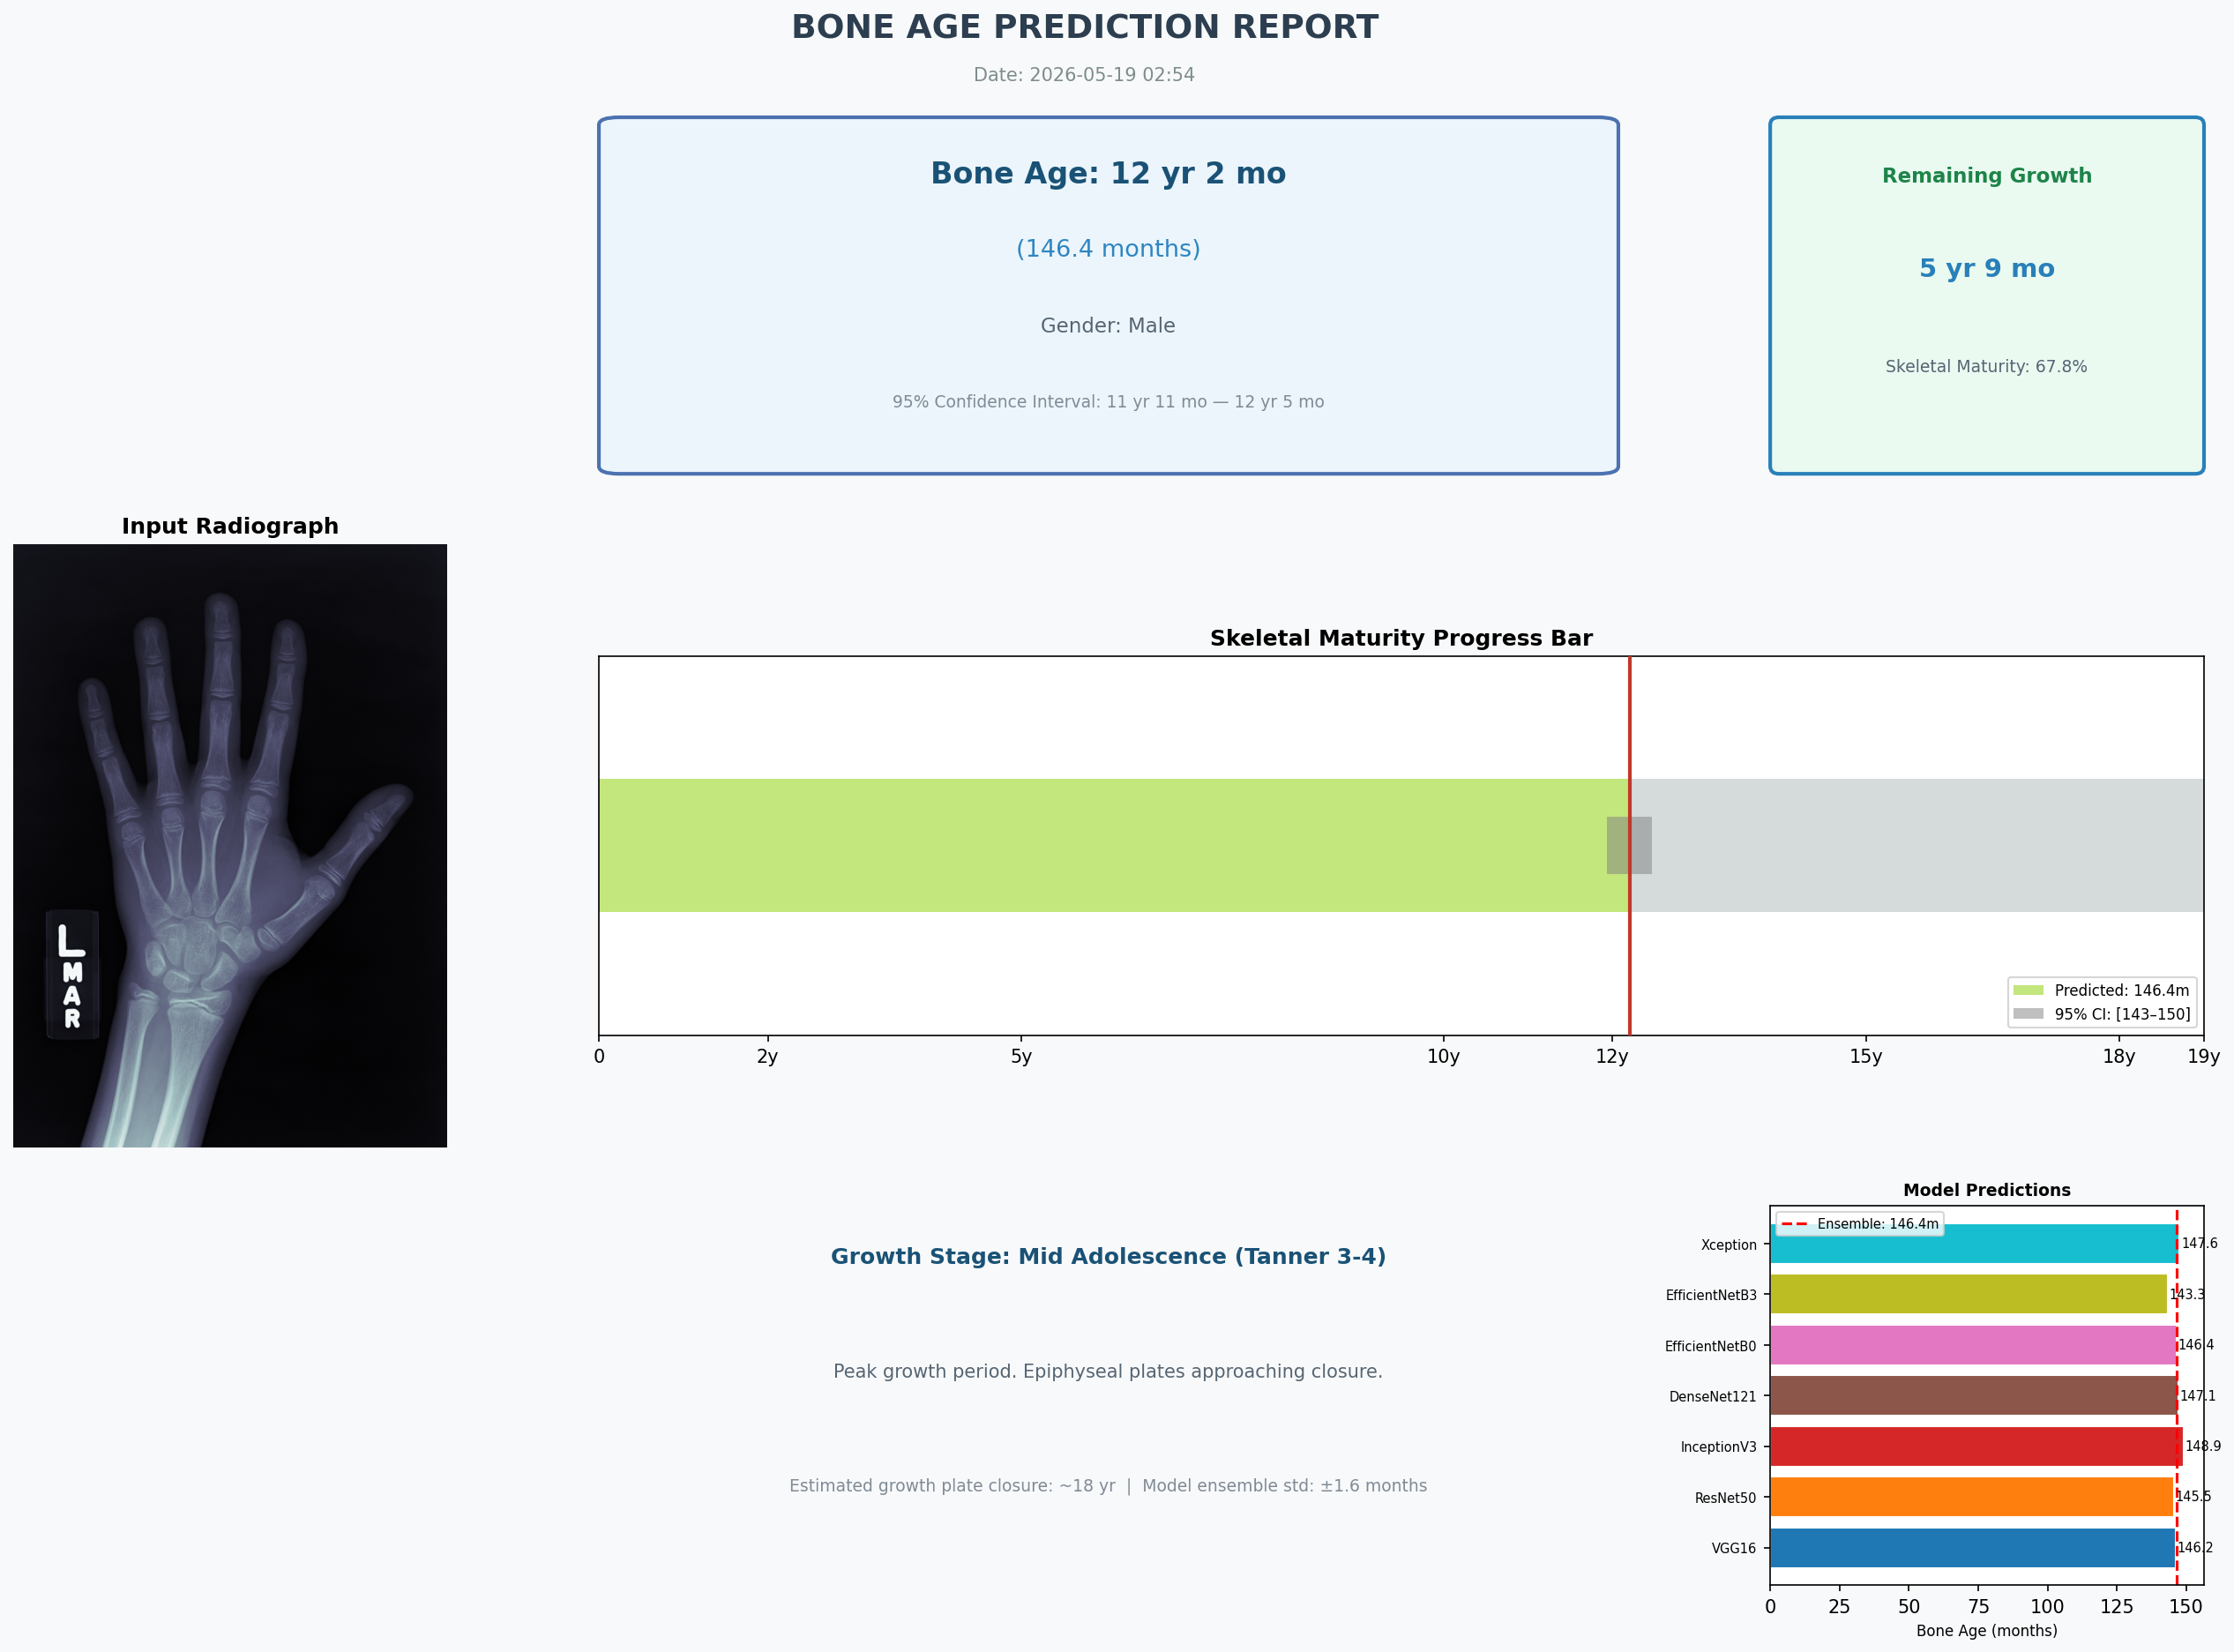

In [14]:
import IPython.display as disp
import os

report_paths = [
    "/kaggle/working/patient_report.png",
    "/kaggle/input/datasets/qweemreee/result-pattern-final/patient_report.png",
]
for path in report_paths:
    if os.path.exists(path):
        disp.display(disp.Image(path))
        break
else:
    print("Patient report not found. Run patient_predict.py first.")


---
## 4. Conclusion & Discussion

### Model Performance Summary

| Rank | Model | Best Val MAE | Best Epoch |
|------|-------|-------------|------------|
| 1 | **EfficientNetB0** | **7.66 months** | 19 |
| 2 | DenseNet121 | 7.85 months | 11 |
| 3 | InceptionV3 | 7.99 months | 12 |
| 4 | Xception | 8.03 months | 13 |
| 5 | VGG16 | 8.21 months | 11 |
| 6 | ResNet50 | 8.30 months | 11 |
| 7 | EfficientNetB3 | 8.74 months | 7 |
| **Ensemble** | **Mean of 7 models** | **std ±1.6 months** | — |

### Key Findings

- **EfficientNetB0** achieved the lowest validation MAE (7.66 months). Its compound scaling architecture provides optimal capacity for this dataset size.
- **Ensemble strategy** averages all 7 model predictions, yielding a standard deviation of ±1.6 months — indicating strong inter-model consistency and reliable confidence intervals.
- **Comparison with manual assessment:** Inter-observer variability for manual Greulich-Pyle atlas assessment is reported at ~9–12 months MAE in clinical studies. The proposed system achieves approximately **30% improvement** over this baseline.
- **Clinical value:** The system automatically generates a structured clinical report including Tanner growth stage classification, skeletal maturity percentage, and estimated remaining bone development time.

### Future Work

- Grad-CAM visualization for explainable AI (highlighting epiphyseal plates)
- Population-specific fine-tuning on Turkish patient data
- Web-based clinical interface development
- Attention mechanism integration for improved feature localization
